# Proyecto Bucephalus — Modelado científico y comparación experimental

Notebook definitivo del TFM Bucephalus.

## Fuentes oficiales de datos

Este notebook queda preparado para consumir las fuentes definitivas del proyecto en Google Cloud. El dataset final de modelado se lee desde BigQuery: `project-bucephalus.baseline_v5final.baseline`. Los datos raw se leen desde Google Cloud Storage: `gs://bucephalus-bucket1/datasets_raw`. Todos los ficheros raw se tratan como CSV salvo `caballos_con_ids_progenitores`, que se carga como Excel (`.xlsx`).

La lectura local se conserva únicamente como mecanismo de contingencia para entornos sin credenciales de Google Cloud, pero no constituye la fuente canónica del TFM.


In [22]:
import os
import re
from pathlib import Path
import numpy as np
import pandas as pd
from google.colab import auth

# Authenticate if running in Colab or Vertex AI
auth.authenticate_user()

BQ_PROJECT = 'project-bucephalus'
BQ_DATASET = 'baseline_v5final'
BQ_TABLE   = 'baseline'
BQ_FULL_TABLE = f'{BQ_PROJECT}.{BQ_DATASET}.{BQ_TABLE}'

GCS_BUCKET = 'bucephalus-bucket1'
GCS_RAW_PREFIX = 'datasets_raw'
GCS_RAW_URI = f'gs://{GCS_BUCKET}/{GCS_RAW_PREFIX}'

USE_BIGQUERY = True
ALLOW_LOCAL_FALLBACK = True
LOCAL_PROCESSED = Path('../data/processed')
LOCAL_RAW = Path('../data/raw')

DATE_COL = 'fecha'
RACE_ID_COL = 'race_id'
HORSE_ID_COL = 'caballo_id'
TARGET_COL = 'target_top3'
WIN_TARGET_COL = 'target_top1'
POSITION_COL = 'pos'


def load_final_dataset(use_bigquery: bool = USE_BIGQUERY) -> pd.DataFrame:
    """Carga el dataset final desde BigQuery y, solo si se permite, cae a parquet local."""
    if use_bigquery:
        try:
            from google.cloud import bigquery
            client = bigquery.Client(project=BQ_PROJECT)
            query = f"SELECT * FROM `{BQ_FULL_TABLE}`"
            df = client.query(query).to_dataframe(create_bqstorage_client=True)
            print(f'BigQuery: {BQ_FULL_TABLE} -> {df.shape[0]:,} filas x {df.shape[1]:,} columnas')
            return df
        except Exception as exc:
            if not ALLOW_LOCAL_FALLBACK:
                raise
            print(f'AVISO: no se pudo leer BigQuery ({exc}). Se usará parquet local como contingencia.')
    candidates = [
        LOCAL_PROCESSED / 'master_v5_final.parquet',
        Path('/home/ubuntu/Proyecto-Bucephalus/data/processed/master_v5_final.parquet'),
        Path('/home/ubuntu/upload/master_v5_final.parquet'),
    ]
    for path in candidates:
        if path.exists():
            df = pd.read_parquet(path)
            print(f'Parquet local de contingencia: {path} -> {df.shape[0]:,} filas x {df.shape[1]:,} columnas')
            return df
    raise FileNotFoundError('No se pudo cargar el dataset final ni desde BigQuery ni desde parquet local.')


def gcs_raw_path(filename: str) -> str:
    return f'{GCS_RAW_URI}/{filename}'


def load_raw_dataset(stem_or_filename: str, **kwargs) -> pd.DataFrame:
    """Carga un raw desde GCS. `caballos_con_ids_progenitores` se fuerza a Excel."""
    name = stem_or_filename
    lower = name.lower()
    if 'caballos_con_ids_progenitores' in lower:
        if not lower.endswith(('.xlsx', '.xls')):
            name = re.sub(r'\.(csv|parquet|xlsx|xls)$', '', name, flags=re.I) + '.xlsx'
        path = gcs_raw_path(name)
        return pd.read_excel(path, **kwargs)
    if not lower.endswith('.csv'):
        name = re.sub(r'\.(csv|parquet|xlsx|xls)$', '', name, flags=re.I) + '.csv'
    path = gcs_raw_path(name)
    return pd.read_csv(path, **kwargs)


def prepare_modelable_dataset(df: pd.DataFrame, min_field_size: int = 3) -> pd.DataFrame:
    """
    Aplica los filtros canónicos del dataset definitivo del TFM.

    Reglas:
    - Fechas normalizadas a UTC.
    - Solo carreras hasta carrera_id <= 11926.
    - Targets construidos desde pos si no existen.
    - Se eliminan carreras con menos de min_field_size participantes.
    """
    out = df.copy()

    if 'fecha' in out.columns:
        out['fecha'] = pd.to_datetime(out['fecha'], errors='coerce', utc=True)

    if 'carrera_id' in out.columns:
        out = out[pd.to_numeric(out['carrera_id'], errors='coerce') <= 11926]

    if 'fecha' in out.columns:
        out = out[
            out['fecha'].between(
                pd.Timestamp('1990-01-01', tz='UTC'),
                pd.Timestamp('2025-12-31', tz='UTC')
            )
        ]

    if 'target_top3' not in out.columns and 'pos' in out.columns:
        pos = pd.to_numeric(out['pos'], errors='coerce')
        valid = pos.notna() & (pos > 0) & (pos < 90)
        out['target_top1'] = (valid & (pos == 1)).astype(int)
        out['target_top3'] = (valid & (pos <= 3)).astype(int)

    group_col = 'race_id' if 'race_id' in out.columns else 'carrera_id'

    if group_col in out.columns:
        sizes = out.groupby(group_col)[group_col].transform('size')
        out = out[sizes >= min_field_size]

    return out.reset_index(drop=True)


def temporal_split_by_race_ratio(
    df: pd.DataFrame,
    train_frac: float = 0.70,
    val_frac: float = 0.20,
    date_col: str = 'fecha'
):
    """
    Split temporal por carreras completas.

    Importante:
    - No separa participantes de una misma carrera entre train/val/test.
    - Ordena las carreras por fecha.
    - Aplica 70/20/10 real por número de carreras, no por fecha fija.
    """
    out = prepare_modelable_dataset(df)

    group_col = 'race_id' if 'race_id' in out.columns else 'carrera_id'

    if date_col not in out.columns:
        raise ValueError(f"No existe la columna de fecha: {date_col}")

    races = (
        out[[group_col, date_col]]
        .dropna(subset=[group_col, date_col])
        .groupby(group_col, as_index=False)[date_col]
        .min()
        .sort_values([date_col, group_col])
        .reset_index(drop=True)
    )

    n_races = len(races)

    if n_races == 0:
        raise ValueError("No hay carreras válidas después de preparar el dataset.")

    n_train = int(n_races * train_frac)
    n_val = int(n_races * val_frac)

    train_races = set(races.iloc[:n_train][group_col])
    val_races = set(races.iloc[n_train:n_train + n_val][group_col])
    test_races = set(races.iloc[n_train + n_val:][group_col])

    train = out[out[group_col].isin(train_races)].copy()
    val = out[out[group_col].isin(val_races)].copy()
    test = out[out[group_col].isin(test_races)].copy()

    sort_cols = [date_col, group_col]
    if 'caballo_id' in out.columns:
        sort_cols.append('caballo_id')

    train = train.sort_values(sort_cols, na_position='last').reset_index(drop=True)
    val = val.sort_values(sort_cols, na_position='last').reset_index(drop=True)
    test = test.sort_values(sort_cols, na_position='last').reset_index(drop=True)

    # Sanity checks: ninguna carrera puede aparecer en más de un split
    assert set(train[group_col]).isdisjoint(set(val[group_col]))
    assert set(train[group_col]).isdisjoint(set(test[group_col]))
    assert set(val[group_col]).isdisjoint(set(test[group_col]))

    return train, val, test

# Política de variables post-carrera / cuarentena metodológica
# -----------------------------------------------------------
# `pos` es la etiqueta bruta de llegada; solo se usa para construir targets y auditoría.
# `distancia_al_anterior` y variantes (`dist_al_anterior`) solo existen después de la carrera.
# `odds_win`/`dividendo_ganador` se reserva para baseline de mercado o ROI, nunca para el modelo científico principal.
POST_RACE_COLS = {
    'pos', 'target_top1', 'target_top3', 'target_pos', 'target_rank_label',
    'distancia_al_anterior', 'dist_al_anterior', 'race_has_winner',
    'odds_win', 'dividendo_ganador', 'dividendo_colocado', 'payout_win'
}
IDENTIFIER_COLS = {
    'carrera_id', 'race_id', 'caballo_id', 'jinete_id', 'preparador_id',
    'padre_id', 'madre_id', 'abuelo_id', 'criador_id', 'jornada_id'
}
TEXT_COLS = {
    'nombre', 'caballo_nombre', 'jinete_nombre', 'preparador_nombre',
    'hipodromo', 'carrera_nombre', 'condiciones', 'padre___madre', 'pista'
}
DATE_COLS = {'fecha'}

def get_feature_columns(df: pd.DataFrame, include_odds: bool = False, include_quarantine: bool = False) -> list[str]:
    '''Devuelve features numéricas conocidas antes de la salida de la carrera.

    Por defecto excluye variables post-carrera, identificadores puros, textos y targets.
    `include_odds=True` solo debe usarse en notebooks de ROI o baseline de mercado.
    '''
    quarantine = set()
    if not include_quarantine:
        quarantine |= POST_RACE_COLS
    if include_odds:
        quarantine -= {'odds_win'}
    else:
        quarantine |= {'odds_win'}
    exclude = quarantine | IDENTIFIER_COLS | TEXT_COLS | DATE_COLS
    exclude |= {c for c in df.columns if c.startswith('target_')}
    cols = []
    for c in df.columns:
        if c in exclude:
            continue
        # Removed the dtype check to get all valid feature columns
        cols.append(c)
    forbidden = sorted((set(cols) & POST_RACE_COLS) - ({'odds_win'} if include_odds else set()))
    if forbidden:
        raise ValueError(f'Features con leakage detectadas: {forbidden}')
    return cols

# Proyecto Bucephalus — Modelado Completo

**Versión científica reproducible**

Este cuaderno entrena, evalúa y compara modelos para predecir `target_top3` (caballo entra en top-3) bajo un esquema **walk-forward holdout** estricto:

- **Train**: 1997-01-19 → 2016-05-29 (70%)
- **Val**:   2016-06-03 → 2021-12-28 (20%)
- **Test**:  2024-10-01 → 2025-04-02 (10%)

## Modelos

| Familia | Modelo | Notas |
|---|---|---|
| **Baselines** | Bayes (tasa global), Posición de salida (`casilla`) | Sanity checks |
| **Tree-based clasificadores** | RandomForest, LightGBM, XGBoost, CatBoost | `early_stopping` con val |
| **Tree-based rankers** | LGBMRanker, XGBRanker | Objetivo LambdaRank, group=carrera |
| **Redes Tabulares** | TabM (PLE + k-ensemble), TabTransformer (embeddings + Transformer) | PyTorch |
| **HPO** | LightGBM via Optuna (TPE, NDCG@3) | 30 trials |

## Métricas

- **Clasificación**: AUC, F1, Brier (con bootstrap CI 95%)
- **Ranking dentro de carrera**: NDCG@3, MAP@3, P@3, HR@1, HR@3, Spearman ρ
- **Comparación entre modelos**: Wilcoxon signed-rank pareado sobre NDCG@3 por carrera
- **Calibración**: Reliability diagram + ECE
- **Interpretabilidad**: SHAP TreeExplainer

**Exclusión rigurosa de post-race features**: `pos`, `distancia_al_anterior`/`dist_al_anterior`, `target_*`, `race_has_winner`; `odds_win` solo se admite en baseline de mercado/ROI (definido en `feature_meta.json` del notebook 03).


In [23]:
import os, sys, json, pickle, warnings, time, hashlib
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr, wilcoxon
from sklearn.metrics import (roc_auc_score, f1_score, brier_score_loss,
                              average_precision_score)
from sklearn.calibration import calibration_curve
from IPython.display import display

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 80)
pd.set_option('display.float_format', '{:.4f}'.format)
sns.set_theme(style='whitegrid', font_scale=1.0)
plt.rcParams.update({'figure.dpi': 110, 'figure.figsize': (13, 4.5)})

ROOT = Path(os.getcwd())
if ROOT.name == 'notebooks': ROOT = ROOT.parent
PROCESSED  = ROOT / 'data' / 'processed'
MODELS_DIR = ROOT / 'data' / 'models'
REPORTS    = ROOT / 'data' / 'reports'
REPORTS.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

try:
    from google.colab import drive
    DRIVE = Path('/content/drive/MyDrive/Bucephalus')
    if not DRIVE.exists(): drive.mount('/content/drive', force_remount=False)
    if DRIVE.exists():
        PROCESSED  = DRIVE / 'data' / 'processed'
        MODELS_DIR = DRIVE / 'data' / 'models'
except ImportError: pass

SEED = 42
np.random.seed(SEED)
import random; random.seed(SEED)

import torch
torch.manual_seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')
print(f'Run timestamp: {datetime.now().isoformat(timespec="seconds")}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Device: cuda
Run timestamp: 2026-05-30T06:47:14


In [24]:
# ============================================================
# CHECKPOINT CONFIG
# ============================================================

from pathlib import Path
import json
import time
import joblib
import numpy as np
import pandas as pd
from datetime import datetime

# Si ya tienes REPORTS / MODELS_DIR definidos, usa esos.
# Si no, se crean rutas locales por defecto.
if "REPORTS" not in globals():
    REPORTS = Path("reports")
    REPORTS.mkdir(parents=True, exist_ok=True)

if "MODELS_DIR" not in globals():
    MODELS_DIR = Path("models")
    MODELS_DIR.mkdir(parents=True, exist_ok=True)

CHECKPOINT_DIR = REPORTS / "checkpoints"
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

PREDICTIONS_CHECKPOINT = CHECKPOINT_DIR / "test_predictions_latest.npz"
VAL_PREDICTIONS_CHECKPOINT = CHECKPOINT_DIR / "val_predictions_latest.npz"
TEST_RESULTS_CHECKPOINT = CHECKPOINT_DIR / "model_results_test_latest.csv"
VAL_RESULTS_CHECKPOINT = CHECKPOINT_DIR / "model_results_val_latest.csv"
PER_RACE_CHECKPOINT = CHECKPOINT_DIR / "per_race_metrics_test_latest.csv"
MANIFEST_CHECKPOINT = CHECKPOINT_DIR / "checkpoint_manifest.json"

print("Checkpoint dir:", CHECKPOINT_DIR.resolve())

Checkpoint dir: /content/data/reports/checkpoints


In [25]:
# ============================================================
# GLOBAL PREDICTION REGISTRY
# ============================================================

# Estos diccionarios sobreviven mientras viva el kernel.
# Además, cada vez que guardemos checkpoint se persistirán en disco.
val_predictions_registry = {}
test_predictions_registry = {}

def register_predictions(model_name, pred_val=None, pred_test=None):
    """
    Registra predicciones de un modelo en memoria.
    Luego save_checkpoint() las guarda a disco.
    """
    global val_predictions_registry, test_predictions_registry

    if pred_val is not None:
        val_predictions_registry[model_name] = np.asarray(pred_val)

    if pred_test is not None:
        test_predictions_registry[model_name] = np.asarray(pred_test)

    print(f"✅ Predicciones registradas para: {model_name}")
    print(f"   Val registry:  {list(val_predictions_registry.keys())}")
    print(f"   Test registry: {list(test_predictions_registry.keys())}")

In [26]:
# ============================================================
# CHECKPOINT FUNCTIONS
# ============================================================

def _results_to_dataframe(results):
    """
    Convierte val_results/test_results a DataFrame sin objetos internos tipo _per_race.
    """
    if results is None or len(results) == 0:
        return pd.DataFrame()

    df = pd.DataFrame([
        {k: v for k, v in r.items() if not str(k).startswith("_")}
        for r in results
    ])

    if "NDCG@3" in df.columns:
        df = df.sort_values("NDCG@3", ascending=False).reset_index(drop=True)

    return df


def _per_race_to_dataframe(results):
    """
    Extrae métricas por carrera desde full_eval(), si existen.
    """
    if results is None or len(results) == 0:
        return pd.DataFrame()

    chunks = []

    for r in results:
        if "_per_race" in r:
            tmp = r["_per_race"].copy()
            tmp["model"] = r.get("model", "unknown")
            chunks.append(tmp)

    if not chunks:
        return pd.DataFrame()

    return pd.concat(chunks, ignore_index=True)


def save_checkpoint(
    checkpoint_name="latest",
    save_models_dict=None,
    extra_manifest=None
):
    """
    Guarda todo lo importante:
    - tabla global test
    - tabla global val
    - predicciones test
    - predicciones val
    - métricas por carrera
    - modelos opcionales
    - manifest JSON
    """
    global val_results, test_results
    global val_predictions_registry, test_predictions_registry

    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

    ckpt_dir = CHECKPOINT_DIR / checkpoint_name
    ckpt_dir.mkdir(parents=True, exist_ok=True)

    # ----------------------------
    # 1. Resultados globales
    # ----------------------------
    test_df = _results_to_dataframe(test_results if "test_results" in globals() else [])
    val_df = _results_to_dataframe(val_results if "val_results" in globals() else [])

    if len(test_df) > 0:
        test_df.to_csv(ckpt_dir / "model_results_test.csv", index=False)
        test_df.to_csv(TEST_RESULTS_CHECKPOINT, index=False)

    if len(val_df) > 0:
        val_df.to_csv(ckpt_dir / "model_results_val.csv", index=False)
        val_df.to_csv(VAL_RESULTS_CHECKPOINT, index=False)

    # ----------------------------
    # 2. Métricas por carrera
    # ----------------------------
    per_race_df = _per_race_to_dataframe(test_results if "test_results" in globals() else [])

    if len(per_race_df) > 0:
        per_race_df.to_csv(ckpt_dir / "per_race_metrics_test.csv", index=False)
        per_race_df.to_csv(PER_RACE_CHECKPOINT, index=False)

    # ----------------------------
    # 3. Predicciones test
    # ----------------------------
    test_payload = {}

    if "y_test" in globals():
        test_payload["y_test"] = np.asarray(y_test)

    if "grp_test" in globals():
        test_payload["carrera_id"] = np.asarray(grp_test)
    elif "df_test" in globals():
        group_col = "race_id" if "race_id" in df_test.columns else "carrera_id"
        if group_col in df_test.columns:
            test_payload["carrera_id"] = np.asarray(df_test[group_col].values)

    for name, pred in test_predictions_registry.items():
        test_payload[name] = np.asarray(pred)

    if len(test_payload) > 0:
        np.savez_compressed(ckpt_dir / "test_predictions.npz", **test_payload)
        np.savez_compressed(PREDICTIONS_CHECKPOINT, **test_payload)

    # ----------------------------
    # 4. Predicciones val
    # ----------------------------
    val_payload = {}

    if "y_val" in globals():
        val_payload["y_val"] = np.asarray(y_val)

    if "grp_val" in globals():
        val_payload["carrera_id"] = np.asarray(grp_val)
    elif "df_val" in globals():
        group_col = "race_id" if "race_id" in df_val.columns else "carrera_id"
        if group_col in df_val.columns:
            val_payload["carrera_id"] = np.asarray(df_val[group_col].values)

    for name, pred in val_predictions_registry.items():
        val_payload[name] = np.asarray(pred)

    if len(val_payload) > 0:
        np.savez_compressed(ckpt_dir / "val_predictions.npz", **val_payload)
        np.savez_compressed(VAL_PREDICTIONS_CHECKPOINT, **val_payload)

    # ----------------------------
    # 5. Guardado de modelos opcionales
    # ----------------------------
    saved_models = []

    if save_models_dict:
        models_out = ckpt_dir / "models"
        models_out.mkdir(parents=True, exist_ok=True)

        for model_name, model_obj in save_models_dict.items():
            try:
                path = models_out / f"{model_name}.pkl"
                joblib.dump(model_obj, path)
                saved_models.append(str(path))
            except Exception as e:
                print(f"⚠️ No se pudo guardar modelo {model_name}: {e}")

    # ----------------------------
    # 6. Manifest
    # ----------------------------
    manifest = {
        "checkpoint_name": checkpoint_name,
        "saved_at": datetime.now().isoformat(timespec="seconds"),
        "timestamp": timestamp,
        "checkpoint_dir": str(ckpt_dir),
        "n_test_results": int(len(test_df)),
        "n_val_results": int(len(val_df)),
        "test_models": list(test_df["model"]) if "model" in test_df.columns else [],
        "val_models": list(val_df["model"]) if "model" in val_df.columns else [],
        "test_prediction_keys": list(test_payload.keys()),
        "val_prediction_keys": list(val_payload.keys()),
        "has_per_race": bool(len(per_race_df) > 0),
        "saved_models": saved_models,
    }

    if "train" in globals() and "val" in globals() and "test" in globals():
        group_col = "race_id" if "race_id" in train.columns else "carrera_id"
        manifest.update({
            "n_train_rows": int(len(train)),
            "n_val_rows": int(len(val)),
            "n_test_rows": int(len(test)),
            "n_train_races": int(train[group_col].nunique()) if group_col in train.columns else None,
            "n_val_races": int(val[group_col].nunique()) if group_col in val.columns else None,
            "n_test_races": int(test[group_col].nunique()) if group_col in test.columns else None,
        })

    if extra_manifest:
        manifest.update(extra_manifest)

    with open(ckpt_dir / "manifest.json", "w") as f:
        json.dump(manifest, f, indent=2)

    with open(MANIFEST_CHECKPOINT, "w") as f:
        json.dump(manifest, f, indent=2)

    print(f"✅ Checkpoint guardado: {ckpt_dir}")
    print(f"   Test results: {len(test_df)} modelos")
    print(f"   Test predictions: {list(test_payload.keys())}")
    print(f"   Per-race guardado: {len(per_race_df) > 0}")

    if len(test_df) > 0:
        display(test_df)

    return manifest

In [27]:
# ============================================================
# CHECKPOINT RECOVERY FUNCTIONS
# ============================================================

def load_latest_results():
    """
    Carga la última tabla global guardada.
    """
    if TEST_RESULTS_CHECKPOINT.exists():
        df = pd.read_csv(TEST_RESULTS_CHECKPOINT)
        print(f"✅ Tabla test cargada desde: {TEST_RESULTS_CHECKPOINT}")
        display(df)
        return df

    print("❌ No existe tabla global test guardada.")
    return pd.DataFrame()


def load_latest_predictions(split="test"):
    """
    Carga predicciones guardadas en NPZ.
    """
    path = PREDICTIONS_CHECKPOINT if split == "test" else VAL_PREDICTIONS_CHECKPOINT

    if path.exists():
        data = np.load(path)
        print(f"✅ Predicciones {split} cargadas desde: {path}")
        print("Claves:", data.files)
        return data

    print(f"❌ No existen predicciones {split} guardadas.")
    return None


def reconstruct_test_results_from_predictions(df_test, prediction_npz=None):
    """
    Reconstruye test_results desde predicciones guardadas.
    Necesita que full_eval esté definido y que df_test esté reconstruido.
    """
    if prediction_npz is None:
        prediction_npz = load_latest_predictions("test")

    if prediction_npz is None:
        raise ValueError("No hay predicciones guardadas.")

    if "full_eval" not in globals():
        raise ValueError("full_eval no está definido. Ejecuta antes la celda de métricas.")

    reconstructed = []

    skip_keys = {"y_test", "carrera_id"}

    for key in prediction_npz.files:
        if key in skip_keys:
            continue

        pred = prediction_npz[key]
        reconstructed.append(full_eval(key, df_test, pred))

    print(f"✅ Reconstruidos {len(reconstructed)} modelos en test_results.")
    return reconstructed

## 1. Carga de Datos y Artefactos del Notebook 03

In [28]:
# Lectura canónica del dataset final y generación de splits temporales por carrera
df = load_final_dataset()

train, val, test = temporal_split_by_race_ratio(
    df,
    train_frac=0.70,
    val_frac=0.20,
    date_col='fecha'
)

feature_cols = get_feature_columns(
    train,
    include_odds=False,
    include_quarantine=False
)
# ============================================================
# EXCLUSIÓN METODOLÓGICA — familia wr_distancia_m
# ============================================================
# Motivo:
# distancia_m es una variable de carrera, constante para todos los participantes.
# Sus transformaciones within-race no aportan comparación entre caballos y pueden
# introducir señales degeneradas o espurias.

BAD_DISTANCE_WR_PATTERNS = [
    "wr_distancia_m",
]

removed_bad_distance_wr_features = [
    c for c in feature_cols
    if any(p in c for p in BAD_DISTANCE_WR_PATTERNS)
]

feature_cols = [
    c for c in feature_cols
    if c not in removed_bad_distance_wr_features
]

print("Variables within-race de distancia eliminadas:")
for c in removed_bad_distance_wr_features:
    print("-", c)

print(f"Nº variables eliminadas: {len(removed_bad_distance_wr_features)}")
print(f"Nº final de FEATURE_COLS: {len(feature_cols)}")
print(f"distancia_m se mantiene: {'distancia_m' in feature_cols}")
print(f'Features candidatas sin leakage: {len(feature_cols)}')

GROUP_COL = 'race_id' if 'race_id' in train.columns else 'carrera_id'

def split_report(train, val, test, group_col=GROUP_COL, target_col=TARGET_COL, date_col='fecha'):
    rows = []

    total_rows = len(train) + len(val) + len(test)
    total_races = (
        train[group_col].nunique()
        + val[group_col].nunique()
        + test[group_col].nunique()
    )

    for name, part in [('train', train), ('val', val), ('test', test)]:
        rows.append({
            'split': name,
            'rows': len(part),
            'rows_pct': len(part) / total_rows,
            'races': part[group_col].nunique(),
            'races_pct': part[group_col].nunique() / total_races,
            'avg_participants_per_race': len(part) / part[group_col].nunique(),
            'target_top3_rate': part[target_col].mean(),
            'date_min': part[date_col].min(),
            'date_max': part[date_col].max(),
        })

    return pd.DataFrame(rows)

display(split_report(train, val, test))


BigQuery: project-bucephalus.baseline_v5final.baseline -> 101,976 filas x 215 columnas
Variables within-race de distancia eliminadas:
- wr_distancia_m_race_rank
- wr_distancia_m_race_pct
- wr_distancia_m_race_zscore
- wr_distancia_m_race_mean
- wr_distancia_m_diff_race_mean
Nº variables eliminadas: 5
Nº final de FEATURE_COLS: 186
distancia_m se mantiene: True
Features candidatas sin leakage: 186


,split,rows,rows_pct,races,races_pct,avg_participants_per_race,target_top3_rate,date_min,date_max
0,train,73807,0.7239,7925,0.7000,9.3132,0.3221,1997-08-17 00:00:00+00:00,2017-03-05 00:00:00+00:00
1,val,19242,0.1887,2264,0.2000,8.4991,0.3528,2017-03-05 00:00:00+00:00,2022-06-15 00:00:00+00:00
2,test,8909,0.0874,1133,0.1001,7.8632,0.3816,2022-06-19 00:00:00+00:00,2025-04-02 00:00:00+00:00


In [29]:
# ============================================================
# AUDITORÍA METODOLÓGICA — wr_distancia_m_race_pct
# ============================================================

import pandas as pd
import numpy as np

SUSPICIOUS_FEATURE = "wr_distancia_m_race_pct"
GROUP_COL = "race_id" if "race_id" in train.columns else "carrera_id"

df_all_audit = pd.concat([train, val, test], ignore_index=True)

print(f"Variable auditada: {SUSPICIOUS_FEATURE}")
print(f"Existe en FEATURE_COLS: {SUSPICIOUS_FEATURE in feature_cols}")
print(f"Existe en df_all_audit: {SUSPICIOUS_FEATURE in df_all_audit.columns}")

if SUSPICIOUS_FEATURE in df_all_audit.columns:

    audit_wr = (
        df_all_audit
        .groupby(GROUP_COL)[SUSPICIOUS_FEATURE]
        .agg(["nunique", "min", "max", "mean", "std"])
        .reset_index()
    )

    print("\nDistribución de nunique dentro de carrera para wr_distancia_m_race_pct:")
    display(audit_wr["nunique"].value_counts().sort_index())

    display(
        audit_wr
        .sort_values("nunique", ascending=False)
        .head(20)
    )

    if "distancia_m" in df_all_audit.columns:
        audit_dist = (
            df_all_audit
            .groupby(GROUP_COL)["distancia_m"]
            .agg(["nunique", "min", "max"])
            .reset_index()
        )

        print("\nDistribución de nunique dentro de carrera para distancia_m:")
        display(audit_dist["nunique"].value_counts().sort_index())

        display(
            audit_dist
            .sort_values("nunique", ascending=False)
            .head(20)
        )

    if "target_top3" in df_all_audit.columns:
        tmp = df_all_audit[[SUSPICIOUS_FEATURE, "target_top3"]].dropna()
        if len(tmp) > 0:
            corr = tmp[SUSPICIOUS_FEATURE].corr(tmp["target_top3"])
            print(f"\nCorrelación simple con target_top3: {corr:.6f}")

else:
    print("La variable no existe en el dataset actual.")

Variable auditada: wr_distancia_m_race_pct
Existe en FEATURE_COLS: False
Existe en df_all_audit: True

Distribución de nunique dentro de carrera para wr_distancia_m_race_pct:


,count
nunique,
0,1
1,11321


,carrera_id,nunique,min,max,mean,std
11321,11926,1,0.5625,0.5625,0.5625,0.0000
0,92,1,0.6250,0.6250,0.6250,0.0000
1,93,1,0.5333,0.5333,0.5333,0.0000
2,94,1,0.5278,0.5278,0.5278,0.0000
3,95,1,0.5625,0.5625,0.5625,0.0000
4,96,1,0.5417,0.5417,0.5417,0.0000
5,97,1,0.5294,0.5294,0.5294,0.0000
6,103,1,0.5556,0.5556,0.5556,0.0000
7,104,1,0.5500,0.5500,0.5500,0.0000
8,105,1,0.5294,0.5294,0.5294,0.0000



Distribución de nunique dentro de carrera para distancia_m:


,count
nunique,
0,1
1,11321


,carrera_id,nunique,min,max
11321,11926,1,1500.0000,1500.0000
0,92,1,1400.0000,1400.0000
1,93,1,2200.0000,2200.0000
2,94,1,2200.0000,2200.0000
3,95,1,1600.0000,1600.0000
4,96,1,1600.0000,1600.0000
5,97,1,1400.0000,1400.0000
6,103,1,1300.0000,1300.0000
7,104,1,1600.0000,1600.0000
8,105,1,1600.0000,1600.0000



Correlación simple con target_top3: 0.269132


## 2. Métricas de Evaluación con Inferencia Estadística

In [30]:
from sklearn.metrics import ndcg_score

GROUP_COL = RACE_ID_COL

def race_metrics(df_part, scores, k=3):
    """NDCG@k, MAP@k, P@k, HR@1, HR@k, Spearman por carrera."""
    # Determine the correct race ID column dynamically
    group_col_name = 'race_id' if 'race_id' in df_part.columns else 'carrera_id'
    d = pd.DataFrame({'gid': df_part[group_col_name].values,
                       'y':   df_part[TARGET_COL].astype(int).values,
                       's':   scores})
    pos_raw = pd.to_numeric(df_part['pos'], errors='coerce')
    d['pos'] = pos_raw.values
    rows = []
    for gid, g in d.groupby('gid'):
        if len(g) < 2 or g['y'].sum() == 0: continue
        g_sorted = g.sort_values('s', ascending=False)
        topk = g_sorted.head(k)
        n_rel = int(g['y'].sum())
        hits  = int(topk['y'].sum())
        prec  = hits / k
        ap    = 0.0; tp = 0
        for i, (_, r) in enumerate(topk.iterrows(), 1):
            if r['y'] == 1:
                tp += 1; ap += tp / i
        ap = ap / min(k, n_rel) if n_rel > 0 else 0.0
        ndcg = ndcg_score([g['y'].values], [g['s'].values], k=k)
        valid_pos = g.dropna(subset=['pos'])
        rho = np.nan
        if len(valid_pos) >= 3:
            try: rho = -spearmanr(valid_pos['s'], valid_pos['pos']).statistic
            except: pass
        rows.append({'gid': gid, 'ndcg': ndcg, 'ap': ap, 'prec': prec,
                      'hr1': int(g_sorted.iloc[0]['y']), 'hrk': int(hits > 0),
                      'spearman': rho})
    return pd.DataFrame(rows)

def bootstrap_ci(values, B=1000, alpha=0.05, seed=42):
    rng = np.random.default_rng(seed)
    v = np.asarray(values); v = v[~np.isnan(v)]
    if len(v) < 5: return (np.nan, np.nan)
    boot = rng.choice(v, size=(B, len(v)), replace=True).mean(axis=1)
    return np.quantile(boot, alpha/2), np.quantile(boot, 1-alpha/2)

def full_eval(name, df_part, scores, y_true=None):
    if y_true is None: y_true = df_part[TARGET_COL].astype(int).values
    rm = race_metrics(df_part, scores, k=3)
    auc = roc_auc_score(y_true, scores)
    pred_thr = (scores > 0.5).astype(int) if scores.max() <= 1.001 else (scores > np.median(scores)).astype(int)
    f1 = f1_score(y_true, pred_thr)
    brier = brier_score_loss(y_true, np.clip(scores, 0, 1)) if scores.max() <= 1.001 else np.nan
    ndcg_lo, ndcg_hi = bootstrap_ci(rm['ndcg'].values)
    map_lo,  map_hi  = bootstrap_ci(rm['ap'].values)
    return {
        'model': name, 'AUC': auc, 'F1': f1, 'Brier': brier,
        'NDCG@3': rm['ndcg'].mean(), 'NDCG@3_CI': f'[{ndcg_lo:.3f}, {ndcg_hi:.3f}]',
        'MAP@3':  rm['ap'].mean(),   'MAP@3_CI':  f'[{map_lo:.3f}, {map_hi:.3f}]',
        'P@3':    rm['prec'].mean(), 'HR@1':      rm['hr1'].mean(), 'HR@3': rm['hrk'].mean(),
        'Spearman': rm['spearman'].mean(skipna=True), '_per_race': rm
    }

def show_results(results, sort_by='NDCG@3'):
    df_r = pd.DataFrame([{k: v for k, v in r.items() if not k.startswith('_')} for r in results])
    df_r = df_r.sort_values(sort_by, ascending=False).reset_index(drop=True)
    cols_fmt = {c: '{:.4f}' for c in ['AUC','F1','Brier','NDCG@3','MAP@3','P@3','HR@1','HR@3','Spearman']}
    return df_r.style.format({c: f for c, f in cols_fmt.items() if c in df_r.columns}).background_gradient(subset=['NDCG@3','AUC'], cmap='Greens')

test_results = []
val_results  = []
print('Helpers de evaluación listos.')

Helpers de evaluación listos.


## 3. Baselines de Referencia

In [31]:
# Baseline 1: probabilidad uniforme dentro de carrera
scores_uniform = np.random.RandomState(SEED).rand(len(test))
test_results.append(full_eval('Random', test, scores_uniform))
register_predictions("Random", pred_test=scores_uniform)

# Baseline 2: posición de salida (casilla más baja = mejor)
if 'casilla_imputed' in test.columns:
    casilla = test['casilla_imputed'].fillna(test['casilla_imputed'].median()).values
    scores_casilla = -casilla + casilla.max() + 1
    test_results.append(full_eval('Baseline_Casilla', test, scores_casilla))
    register_predictions("Baseline_Casilla", pred_test=scores_casilla)

# Baseline 3: tasa histórica del caballo (rolling)
if 'horse_top3_rate_roll5' in test.columns:
    s = test['horse_top3_rate_roll5'].fillna(train['horse_top3_rate_roll5'].median()).values
    test_results.append(full_eval('Baseline_HorseTop3Roll5', test, s))
    register_predictions("Baseline_HorseTop3Roll5", pred_test=s)

save_checkpoint(
    checkpoint_name="after_baselines"
)

show_results(test_results)

✅ Predicciones registradas para: Random
   Val registry:  []
   Test registry: ['Random']
✅ Predicciones registradas para: Baseline_Casilla
   Val registry:  []
   Test registry: ['Random', 'Baseline_Casilla']
✅ Predicciones registradas para: Baseline_HorseTop3Roll5
   Val registry:  []
   Test registry: ['Random', 'Baseline_Casilla', 'Baseline_HorseTop3Roll5']
✅ Checkpoint guardado: /content/data/reports/checkpoints/after_baselines
   Test results: 3 modelos
   Test predictions: ['y_test', 'carrera_id', 'Random', 'Baseline_Casilla', 'Baseline_HorseTop3Roll5']
   Per-race guardado: True


,model,AUC,F1,Brier,NDCG@3,NDCG@3_CI,MAP@3,MAP@3_CI,P@3,HR@1,HR@3,Spearman
0,Baseline_HorseTop3Roll5,0.6047,0.4405,0.2695,0.5313,"[0.515, 0.547]",0.4289,"[0.412, 0.445]",0.5175,0.5658,0.9029,0.2200
1,Baseline_Casilla,0.5896,0.5019,NaN,0.4596,"[0.443, 0.476]",0.3623,"[0.346, 0.378]",0.4566,0.4669,0.8402,0.0299
2,Random,0.4997,0.4264,0.3318,0.4429,"[0.425, 0.458]",0.3426,"[0.326, 0.358]",0.4360,0.4643,0.8429,-0.0061


,model,AUC,F1,Brier,NDCG@3,NDCG@3_CI,MAP@3,MAP@3_CI,P@3,HR@1,HR@3,Spearman
0,Baseline_HorseTop3Roll5,0.6047,0.4405,0.2695,0.5313,"[0.515, 0.547]",0.4289,"[0.412, 0.445]",0.5175,0.5658,0.9029,0.2200
1,Baseline_Casilla,0.5896,0.5019,nan,0.4596,"[0.443, 0.476]",0.3623,"[0.346, 0.378]",0.4566,0.4669,0.8402,0.0299
2,Random,0.4997,0.4264,0.3318,0.4429,"[0.425, 0.458]",0.3426,"[0.326, 0.358]",0.4360,0.4643,0.8429,-0.0061


In [32]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder
import numpy as np
import pandas as pd

df_train = train.copy()
df_val = val.copy()
df_test = test.copy()

# Target
y_train = train[TARGET_COL].values.astype(np.int32)
y_val = val[TARGET_COL].values.astype(np.int32)
y_test = test[TARGET_COL].values.astype(np.int32)

# Grupos por carrera
GROUP_COL = 'race_id' if 'race_id' in train.columns else 'carrera_id'
grp_train = train[GROUP_COL].values
grp_val = val[GROUP_COL].values
grp_test = test[GROUP_COL].values


# Features: usar siempre la lista ya filtrada contra leakage
NUM_COLS = [
    c for c in feature_cols
    if c in train.columns and (
        pd.api.types.is_numeric_dtype(train[c]) or
        pd.api.types.is_bool_dtype(train[c])
    )
]

ENC_COLS = [
    c for c in feature_cols
    if c in train.columns and c not in NUM_COLS
]

FEATURE_COLS = NUM_COLS + ENC_COLS

# Imputación numérica: fit solo en train
num_imputer = SimpleImputer(strategy='median')
X_train_num = num_imputer.fit_transform(train[NUM_COLS]) if NUM_COLS else np.empty((len(train), 0))
X_val_num = num_imputer.transform(val[NUM_COLS]) if NUM_COLS else np.empty((len(val), 0))
X_test_num = num_imputer.transform(test[NUM_COLS]) if NUM_COLS else np.empty((len(test), 0))

# Codificación categórica: fit solo en train, desconocidos = -1
if ENC_COLS:
    cat_encoder = OrdinalEncoder(
        handle_unknown='use_encoded_value',
        unknown_value=-1,
        encoded_missing_value=-1
    )

    X_train_cat = cat_encoder.fit_transform(
        train[ENC_COLS].astype('string').fillna('__MISSING__')
    )
    X_val_cat = cat_encoder.transform(
        val[ENC_COLS].astype('string').fillna('__MISSING__')
    )
    X_test_cat = cat_encoder.transform(
        test[ENC_COLS].astype('string').fillna('__MISSING__')
    )
else:
    cat_encoder = None
    X_train_cat = np.empty((len(train), 0))
    X_val_cat = np.empty((len(val), 0))
    X_test_cat = np.empty((len(test), 0))

# Matrices finales para modelos de árboles sklearn
X_train_imp = np.hstack([X_train_num, X_train_cat])
X_val_imp = np.hstack([X_val_num, X_val_cat])
X_test_imp = np.hstack([X_test_num, X_test_cat])

print(f'Training features shape: {X_train_imp.shape}')
print(f'Validation features shape: {X_val_imp.shape}')
print(f'Test features shape: {X_test_imp.shape}')
print(f'Numerical columns: {len(NUM_COLS)}')
print(f'Categorical columns: {len(ENC_COLS)}')
print(f'Total model features: {len(FEATURE_COLS)}')

Training features shape: (73807, 186)
Validation features shape: (19242, 186)
Test features shape: (8909, 186)
Numerical columns: 184
Categorical columns: 2
Total model features: 186


## 4. Tree-based Classifiers

In [33]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=400, max_depth=14, min_samples_leaf=20,
                              n_jobs=-1, random_state=SEED, class_weight='balanced_subsample')
t0 = time.time()
rf.fit(X_train_imp, y_train)
pred_rf_val  = rf.predict_proba(X_val_imp)[:, 1]
pred_rf_test = rf.predict_proba(X_test_imp)[:, 1]
print(f'RF entrenado en {time.time()-t0:.1f}s')
val_results.append(full_eval('RandomForest', df_val, pred_rf_val))
test_results.append(full_eval('RandomForest', df_test, pred_rf_test))
register_predictions("RandomForest", pred_rf_val, pred_rf_test)

save_checkpoint(
    checkpoint_name="after_randomforest",
    save_models_dict={"randomforest": rf}
)
show_results(test_results)

RF entrenado en 170.8s
✅ Predicciones registradas para: RandomForest
   Val registry:  ['RandomForest']
   Test registry: ['Random', 'Baseline_Casilla', 'Baseline_HorseTop3Roll5', 'RandomForest']
✅ Checkpoint guardado: /content/data/reports/checkpoints/after_randomforest
   Test results: 4 modelos
   Test predictions: ['y_test', 'carrera_id', 'Random', 'Baseline_Casilla', 'Baseline_HorseTop3Roll5', 'RandomForest']
   Per-race guardado: True


,model,AUC,F1,Brier,NDCG@3,NDCG@3_CI,MAP@3,MAP@3_CI,P@3,HR@1,HR@3,Spearman
0,RandomForest,0.7398,0.6189,0.2155,0.6024,"[0.586, 0.618]",0.5015,"[0.484, 0.518]",0.5822,0.6655,0.9523,0.3558
1,Baseline_HorseTop3Roll5,0.6047,0.4405,0.2695,0.5313,"[0.515, 0.547]",0.4289,"[0.412, 0.445]",0.5175,0.5658,0.9029,0.2200
2,Baseline_Casilla,0.5896,0.5019,NaN,0.4596,"[0.443, 0.476]",0.3623,"[0.346, 0.378]",0.4566,0.4669,0.8402,0.0299
3,Random,0.4997,0.4264,0.3318,0.4429,"[0.425, 0.458]",0.3426,"[0.326, 0.358]",0.4360,0.4643,0.8429,-0.0061


,model,AUC,F1,Brier,NDCG@3,NDCG@3_CI,MAP@3,MAP@3_CI,P@3,HR@1,HR@3,Spearman
0,RandomForest,0.7398,0.6189,0.2155,0.6024,"[0.586, 0.618]",0.5015,"[0.484, 0.518]",0.5822,0.6655,0.9523,0.3558
1,Baseline_HorseTop3Roll5,0.6047,0.4405,0.2695,0.5313,"[0.515, 0.547]",0.4289,"[0.412, 0.445]",0.5175,0.5658,0.9029,0.2200
2,Baseline_Casilla,0.5896,0.5019,nan,0.4596,"[0.443, 0.476]",0.3623,"[0.346, 0.378]",0.4566,0.4669,0.8402,0.0299
3,Random,0.4997,0.4264,0.3318,0.4429,"[0.425, 0.458]",0.3426,"[0.326, 0.358]",0.4360,0.4643,0.8429,-0.0061


In [34]:
# ============================================================
# ABLACIÓN — RandomForest sin wr_distancia_m_race_pct
# ============================================================

from sklearn.ensemble import RandomForestClassifier

ABLATION_COLS = [
    "wr_distancia_m_race_pct"
]

existing_ablation_cols = [c for c in ABLATION_COLS if c in FEATURE_COLS]
missing_ablation_cols = [c for c in ABLATION_COLS if c not in FEATURE_COLS]

print("Variables retiradas existentes:", existing_ablation_cols)
print("Variables no encontradas:", missing_ablation_cols)

if len(existing_ablation_cols) == 0:
    print("No hay variables de ablación en FEATURE_COLS. Se omite la ablación.")
else:
    keep_idx_ablation = [
        i for i, c in enumerate(FEATURE_COLS)
        if c not in existing_ablation_cols
    ]

    feature_cols_ablation = [FEATURE_COLS[i] for i in keep_idx_ablation]

    X_train_abl = X_train_imp[:, keep_idx_ablation]
    X_val_abl   = X_val_imp[:, keep_idx_ablation]
    X_test_abl  = X_test_imp[:, keep_idx_ablation]

    print(f"Features modelo completo: {len(FEATURE_COLS)}")
    print(f"Features modelo ablation: {len(feature_cols_ablation)}")

    rf_no_wr_dist = RandomForestClassifier(
        n_estimators=400,
        max_depth=14,
        min_samples_leaf=20,
        n_jobs=-1,
        random_state=SEED,
        class_weight="balanced_subsample"
    )

    rf_no_wr_dist.fit(X_train_abl, y_train)

    pred_rf_no_wr_dist_val = rf_no_wr_dist.predict_proba(X_val_abl)[:, 1]
    pred_rf_no_wr_dist_test = rf_no_wr_dist.predict_proba(X_test_abl)[:, 1]

    val_results.append(
        full_eval("RandomForest_sin_wr_distancia", df_val, pred_rf_no_wr_dist_val)
    )

    test_results.append(
        full_eval("RandomForest_sin_wr_distancia", df_test, pred_rf_no_wr_dist_test)
    )

    register_predictions(
        "RandomForest_sin_wr_distancia",
        pred_rf_no_wr_dist_val,
        pred_rf_no_wr_dist_test
    )

    comparison_ablation = pd.DataFrame([
        {k: v for k, v in r.items() if not str(k).startswith("_")}
        for r in test_results
        if r["model"] in ["RandomForest", "RandomForest_sin_wr_distancia"]
    ]).sort_values("NDCG@3", ascending=False).reset_index(drop=True)

    display(comparison_ablation)

    comparison_ablation.to_csv(
        REPORTS / "ablation_randomforest_wr_distancia.csv",
        index=False
    )

    save_checkpoint(
        checkpoint_name="after_rf_ablation_wr_distancia",
        save_models_dict={"randomforest_sin_wr_distancia": rf_no_wr_dist},
        extra_manifest={
            "ablation_removed_features": existing_ablation_cols,
            "ablation_n_features": len(feature_cols_ablation)
        }
    )

    show_results(test_results)

Variables retiradas existentes: []
Variables no encontradas: ['wr_distancia_m_race_pct']
No hay variables de ablación en FEATURE_COLS. Se omite la ablación.


In [35]:
import lightgbm as lgb

lgb_train = lgb.Dataset(X_train_imp, y_train, categorical_feature=[FEATURE_COLS.index(c) for c in ENC_COLS])
lgb_val   = lgb.Dataset(X_val_imp,   y_val,   reference=lgb_train,
                          categorical_feature=[FEATURE_COLS.index(c) for c in ENC_COLS])
params = dict(objective='binary', metric='auc', learning_rate=0.05, num_leaves=63,
               min_data_in_leaf=80, feature_fraction=0.85, bagging_fraction=0.85,
               bagging_freq=5, lambda_l2=1.0, verbose=-1, seed=SEED)
t0 = time.time()
lgbm = lgb.train(params, lgb_train, num_boost_round=2000, valid_sets=[lgb_val],
                  callbacks=[lgb.early_stopping(80, verbose=False), lgb.log_evaluation(0)])
print(f'LightGBM entrenado en {time.time()-t0:.1f}s | best_iter={lgbm.best_iteration}')
pred_lgbm_val  = lgbm.predict(X_val_imp)
pred_lgbm_test = lgbm.predict(X_test_imp)
val_results.append(full_eval('LightGBM', df_val, pred_lgbm_val))
test_results.append(full_eval('LightGBM', df_test, pred_lgbm_test))
lgbm.save_model(str(MODELS_DIR / "lightgbm_model.txt"))

register_predictions("LightGBM", pred_lgbm_val, pred_lgbm_test)

save_checkpoint(
    checkpoint_name="after_lightgbm"
)
show_results(test_results)

LightGBM entrenado en 29.6s | best_iter=58
✅ Predicciones registradas para: LightGBM
   Val registry:  ['RandomForest', 'LightGBM']
   Test registry: ['Random', 'Baseline_Casilla', 'Baseline_HorseTop3Roll5', 'RandomForest', 'LightGBM']
✅ Checkpoint guardado: /content/data/reports/checkpoints/after_lightgbm
   Test results: 5 modelos
   Test predictions: ['y_test', 'carrera_id', 'Random', 'Baseline_Casilla', 'Baseline_HorseTop3Roll5', 'RandomForest', 'LightGBM']
   Per-race guardado: True


,model,AUC,F1,Brier,NDCG@3,NDCG@3_CI,MAP@3,MAP@3_CI,P@3,HR@1,HR@3,Spearman
0,RandomForest,0.7398,0.6189,0.2155,0.6024,"[0.586, 0.618]",0.5015,"[0.484, 0.518]",0.5822,0.6655,0.9523,0.3558
1,LightGBM,0.7409,0.4977,0.1963,0.5902,"[0.574, 0.607]",0.4906,"[0.473, 0.508]",0.5699,0.6523,0.9365,0.3412
2,Baseline_HorseTop3Roll5,0.6047,0.4405,0.2695,0.5313,"[0.515, 0.547]",0.4289,"[0.412, 0.445]",0.5175,0.5658,0.9029,0.2200
3,Baseline_Casilla,0.5896,0.5019,NaN,0.4596,"[0.443, 0.476]",0.3623,"[0.346, 0.378]",0.4566,0.4669,0.8402,0.0299
4,Random,0.4997,0.4264,0.3318,0.4429,"[0.425, 0.458]",0.3426,"[0.326, 0.358]",0.4360,0.4643,0.8429,-0.0061


,model,AUC,F1,Brier,NDCG@3,NDCG@3_CI,MAP@3,MAP@3_CI,P@3,HR@1,HR@3,Spearman
0,RandomForest,0.7398,0.6189,0.2155,0.6024,"[0.586, 0.618]",0.5015,"[0.484, 0.518]",0.5822,0.6655,0.9523,0.3558
1,LightGBM,0.7409,0.4977,0.1963,0.5902,"[0.574, 0.607]",0.4906,"[0.473, 0.508]",0.5699,0.6523,0.9365,0.3412
2,Baseline_HorseTop3Roll5,0.6047,0.4405,0.2695,0.5313,"[0.515, 0.547]",0.4289,"[0.412, 0.445]",0.5175,0.5658,0.9029,0.2200
3,Baseline_Casilla,0.5896,0.5019,nan,0.4596,"[0.443, 0.476]",0.3623,"[0.346, 0.378]",0.4566,0.4669,0.8402,0.0299
4,Random,0.4997,0.4264,0.3318,0.4429,"[0.425, 0.458]",0.3426,"[0.326, 0.358]",0.4360,0.4643,0.8429,-0.0061


In [36]:
import xgboost as xgb

dtrain = xgb.DMatrix(X_train_imp, label=y_train)
dval   = xgb.DMatrix(X_val_imp,   label=y_val)
dtest  = xgb.DMatrix(X_test_imp,  label=y_test)
xgb_params = dict(objective='binary:logistic', eval_metric='auc', learning_rate=0.05,
                   max_depth=8, min_child_weight=5, subsample=0.85, colsample_bytree=0.85,
                   reg_lambda=1.0, tree_method='hist', seed=SEED)
t0 = time.time()
bst = xgb.train(xgb_params, dtrain, num_boost_round=2000,
                 evals=[(dval, 'val')], early_stopping_rounds=80, verbose_eval=False)
print(f'XGBoost entrenado en {time.time()-t0:.1f}s | best_iter={bst.best_iteration}')
pred_xgb_val  = bst.predict(dval)
pred_xgb_test = bst.predict(dtest)
val_results.append(full_eval('XGBoost', df_val, pred_xgb_val))
test_results.append(full_eval('XGBoost', df_test, pred_xgb_test))
bst.save_model(str(MODELS_DIR / "xgboost_model.json"))

register_predictions("XGBoost", pred_xgb_val, pred_xgb_test)

save_checkpoint(
    checkpoint_name="after_xgboost"
)
show_results(test_results)

XGBoost entrenado en 21.4s | best_iter=103
✅ Predicciones registradas para: XGBoost
   Val registry:  ['RandomForest', 'LightGBM', 'XGBoost']
   Test registry: ['Random', 'Baseline_Casilla', 'Baseline_HorseTop3Roll5', 'RandomForest', 'LightGBM', 'XGBoost']
✅ Checkpoint guardado: /content/data/reports/checkpoints/after_xgboost
   Test results: 6 modelos
   Test predictions: ['y_test', 'carrera_id', 'Random', 'Baseline_Casilla', 'Baseline_HorseTop3Roll5', 'RandomForest', 'LightGBM', 'XGBoost']
   Per-race guardado: True


,model,AUC,F1,Brier,NDCG@3,NDCG@3_CI,MAP@3,MAP@3_CI,P@3,HR@1,HR@3,Spearman
0,RandomForest,0.7398,0.6189,0.2155,0.6024,"[0.586, 0.618]",0.5015,"[0.484, 0.518]",0.5822,0.6655,0.9523,0.3558
1,XGBoost,0.7437,0.5510,0.1944,0.5935,"[0.578, 0.608]",0.4926,"[0.476, 0.510]",0.5725,0.6584,0.9444,0.3388
2,LightGBM,0.7409,0.4977,0.1963,0.5902,"[0.574, 0.607]",0.4906,"[0.473, 0.508]",0.5699,0.6523,0.9365,0.3412
3,Baseline_HorseTop3Roll5,0.6047,0.4405,0.2695,0.5313,"[0.515, 0.547]",0.4289,"[0.412, 0.445]",0.5175,0.5658,0.9029,0.2200
4,Baseline_Casilla,0.5896,0.5019,NaN,0.4596,"[0.443, 0.476]",0.3623,"[0.346, 0.378]",0.4566,0.4669,0.8402,0.0299
5,Random,0.4997,0.4264,0.3318,0.4429,"[0.425, 0.458]",0.3426,"[0.326, 0.358]",0.4360,0.4643,0.8429,-0.0061


,model,AUC,F1,Brier,NDCG@3,NDCG@3_CI,MAP@3,MAP@3_CI,P@3,HR@1,HR@3,Spearman
0,RandomForest,0.7398,0.6189,0.2155,0.6024,"[0.586, 0.618]",0.5015,"[0.484, 0.518]",0.5822,0.6655,0.9523,0.3558
1,XGBoost,0.7437,0.5510,0.1944,0.5935,"[0.578, 0.608]",0.4926,"[0.476, 0.510]",0.5725,0.6584,0.9444,0.3388
2,LightGBM,0.7409,0.4977,0.1963,0.5902,"[0.574, 0.607]",0.4906,"[0.473, 0.508]",0.5699,0.6523,0.9365,0.3412
3,Baseline_HorseTop3Roll5,0.6047,0.4405,0.2695,0.5313,"[0.515, 0.547]",0.4289,"[0.412, 0.445]",0.5175,0.5658,0.9029,0.2200
4,Baseline_Casilla,0.5896,0.5019,nan,0.4596,"[0.443, 0.476]",0.3623,"[0.346, 0.378]",0.4566,0.4669,0.8402,0.0299
5,Random,0.4997,0.4264,0.3318,0.4429,"[0.425, 0.458]",0.3426,"[0.326, 0.358]",0.4360,0.4643,0.8429,-0.0061


In [37]:
!pip install catboost

In [38]:
try:
    from catboost import CatBoostClassifier, Pool
    import pandas as pd

    # Get categorical feature indices
    cat_idx = [FEATURE_COLS.index(c) for c in ENC_COLS]

    # Create DataFrames from X_imp arrays with FEATURE_COLS for proper column naming
    df_X_train = pd.DataFrame(X_train_imp, columns=FEATURE_COLS)
    df_X_val = pd.DataFrame(X_val_imp, columns=FEATURE_COLS)

    # Convert specified categorical columns to integer type in the DataFrames
    # This allows for mixed dtypes (float for numerical, int for categorical) which CatBoost handles well
    for idx in cat_idx:
        col_name = FEATURE_COLS[idx]
        df_X_train[col_name] = df_X_train[col_name].astype(int)
        df_X_val[col_name] = df_X_val[col_name].astype(int)

    # Create CatBoost Pool objects with the DataFrames
    pool_train = Pool(df_X_train, y_train, cat_features=cat_idx)
    pool_val   = Pool(df_X_val,   y_val,   cat_features=cat_idx)

    cb = CatBoostClassifier(iterations=2000, learning_rate=0.05, depth=8, l2_leaf_reg=3,
                              random_seed=SEED, eval_metric='AUC', od_type='Iter',
                              od_wait=80, verbose=False)
    t0 = time.time()
    cb.fit(pool_train, eval_set=pool_val, use_best_model=True)

    # Prepare prediction data (X_val_imp, X_test_imp) as DataFrames with correct dtypes
    df_X_val_pred = pd.DataFrame(X_val_imp, columns=FEATURE_COLS)
    df_X_test_pred = pd.DataFrame(X_test_imp, columns=FEATURE_COLS)

    for idx in cat_idx:
        col_name = FEATURE_COLS[idx]
        df_X_val_pred[col_name] = df_X_val_pred[col_name].astype(int)
        df_X_test_pred[col_name] = df_X_test_pred[col_name].astype(int)

    # Predict using the newly prepared DataFrames
    pred_cb_val  = cb.predict_proba(df_X_val_pred)[:, 1]
    pred_cb_test = cb.predict_proba(df_X_test_pred)[:, 1]

    print(f'CatBoost entrenado en {time.time()-t0:.1f}s | best_iter={cb.get_best_iteration()}')
    val_results.append(full_eval('CatBoost', df_val, pred_cb_val))
    test_results.append(full_eval('CatBoost', df_test, pred_cb_test))
    cb.save_model(str(MODELS_DIR / "catboost_model.cbm"))

    register_predictions("CatBoost", pred_cb_val, pred_cb_test)

    save_checkpoint(
        checkpoint_name="after_catboost"
    )
except ImportError:
    print('catboost no instalado — omitido')
show_results(test_results)

CatBoost entrenado en 81.7s | best_iter=210
✅ Predicciones registradas para: CatBoost
   Val registry:  ['RandomForest', 'LightGBM', 'XGBoost', 'CatBoost']
   Test registry: ['Random', 'Baseline_Casilla', 'Baseline_HorseTop3Roll5', 'RandomForest', 'LightGBM', 'XGBoost', 'CatBoost']
✅ Checkpoint guardado: /content/data/reports/checkpoints/after_catboost
   Test results: 7 modelos
   Test predictions: ['y_test', 'carrera_id', 'Random', 'Baseline_Casilla', 'Baseline_HorseTop3Roll5', 'RandomForest', 'LightGBM', 'XGBoost', 'CatBoost']
   Per-race guardado: True


,model,AUC,F1,Brier,NDCG@3,NDCG@3_CI,MAP@3,MAP@3_CI,P@3,HR@1,HR@3,Spearman
0,RandomForest,0.7398,0.6189,0.2155,0.6024,"[0.586, 0.618]",0.5015,"[0.484, 0.518]",0.5822,0.6655,0.9523,0.3558
1,XGBoost,0.7437,0.5510,0.1944,0.5935,"[0.578, 0.608]",0.4926,"[0.476, 0.510]",0.5725,0.6584,0.9444,0.3388
2,CatBoost,0.7387,0.5341,0.1956,0.5911,"[0.575, 0.607]",0.4912,"[0.473, 0.508]",0.5728,0.6496,0.9338,0.3395
3,LightGBM,0.7409,0.4977,0.1963,0.5902,"[0.574, 0.607]",0.4906,"[0.473, 0.508]",0.5699,0.6523,0.9365,0.3412
4,Baseline_HorseTop3Roll5,0.6047,0.4405,0.2695,0.5313,"[0.515, 0.547]",0.4289,"[0.412, 0.445]",0.5175,0.5658,0.9029,0.2200
5,Baseline_Casilla,0.5896,0.5019,NaN,0.4596,"[0.443, 0.476]",0.3623,"[0.346, 0.378]",0.4566,0.4669,0.8402,0.0299
6,Random,0.4997,0.4264,0.3318,0.4429,"[0.425, 0.458]",0.3426,"[0.326, 0.358]",0.4360,0.4643,0.8429,-0.0061


,model,AUC,F1,Brier,NDCG@3,NDCG@3_CI,MAP@3,MAP@3_CI,P@3,HR@1,HR@3,Spearman
0,RandomForest,0.7398,0.6189,0.2155,0.6024,"[0.586, 0.618]",0.5015,"[0.484, 0.518]",0.5822,0.6655,0.9523,0.3558
1,XGBoost,0.7437,0.5510,0.1944,0.5935,"[0.578, 0.608]",0.4926,"[0.476, 0.510]",0.5725,0.6584,0.9444,0.3388
2,CatBoost,0.7387,0.5341,0.1956,0.5911,"[0.575, 0.607]",0.4912,"[0.473, 0.508]",0.5728,0.6496,0.9338,0.3395
3,LightGBM,0.7409,0.4977,0.1963,0.5902,"[0.574, 0.607]",0.4906,"[0.473, 0.508]",0.5699,0.6523,0.9365,0.3412
4,Baseline_HorseTop3Roll5,0.6047,0.4405,0.2695,0.5313,"[0.515, 0.547]",0.4289,"[0.412, 0.445]",0.5175,0.5658,0.9029,0.2200
5,Baseline_Casilla,0.5896,0.5019,nan,0.4596,"[0.443, 0.476]",0.3623,"[0.346, 0.378]",0.4566,0.4669,0.8402,0.0299
6,Random,0.4997,0.4264,0.3318,0.4429,"[0.425, 0.458]",0.3426,"[0.326, 0.358]",0.4360,0.4643,0.8429,-0.0061


## 5. Rankers (LambdaRank)

In [39]:
# Etiqueta de relevancia graduada por carrera: usar target_rank_label si existe, sino top3
if 'target_rank_label' in df_train.columns:
    r_train = df_train['target_rank_label'].fillna(0).astype(int).values
    r_val   = df_val['target_rank_label'].fillna(0).astype(int).values
else:
    r_train = y_train
    r_val = y_val

# Group sizes (deben ir ORDENADOS)
def group_sizes(arr):
    s = pd.Series(arr)
    return s.groupby(s, sort=False).size().values

ord_train = np.argsort(grp_train, kind='stable')
ord_val   = np.argsort(grp_val, kind='stable')
ord_test  = np.argsort(grp_test, kind='stable')

g_train = group_sizes(grp_train[ord_train]).astype(np.int32)
g_val   = group_sizes(grp_val[ord_val]).astype(np.int32)
g_test  = group_sizes(grp_test[ord_test]).astype(np.int32)

# LGBMRanker
ranker_lgb = lgb.LGBMRanker(objective='lambdarank', metric='ndcg', ndcg_eval_at=[3],
                              learning_rate=0.05, num_leaves=63, n_estimators=2000,
                              min_data_in_leaf=80, feature_fraction=0.85,
                              bagging_fraction=0.85, bagging_freq=5, seed=SEED, verbose=-1)
ranker_lgb.fit(X_train_imp[ord_train], r_train[ord_train], group=g_train,
                eval_set=[(X_val_imp[ord_val], r_val[ord_val])], eval_group=[g_val],
                callbacks=[lgb.early_stopping(80, verbose=False)])

# Re-score en orden original
score_lgr_val  = np.empty_like(pred_lgbm_val);  score_lgr_val[ord_val]  = ranker_lgb.predict(X_val_imp[ord_val])
score_lgr_test = np.empty_like(pred_lgbm_test); score_lgr_test[ord_test] = ranker_lgb.predict(X_test_imp[ord_test])
val_results.append(full_eval('LGBMRanker', df_val,  score_lgr_val))
test_results.append(full_eval('LGBMRanker', df_test, score_lgr_test))
register_predictions("LGBMRanker", score_lgr_val, score_lgr_test)

save_checkpoint(
    checkpoint_name="after_lgbm_ranker",
    save_models_dict={"lgbm_ranker": ranker_lgb}
)

# XGBRanker
ranker_xgb = xgb.XGBRanker(objective='rank:pairwise', eval_metric='ndcg@3',
                             learning_rate=0.05, max_depth=7, n_estimators=1500,
                             subsample=0.85, colsample_bytree=0.85,
                             tree_method='hist', random_state=SEED,
                             early_stopping_rounds=60, verbosity=0)
ranker_xgb.fit(X_train_imp[ord_train], r_train[ord_train], group=g_train,
                eval_set=[(X_val_imp[ord_val], r_val[ord_val])], eval_group=[g_val], verbose=False)
score_xgr_val  = np.empty_like(pred_lgbm_val);  score_xgr_val[ord_val]  = ranker_xgb.predict(X_val_imp[ord_val])
score_xgr_test = np.empty_like(pred_lgbm_test); score_xgr_test[ord_test] = ranker_xgb.predict(X_test_imp[ord_test])
val_results.append(full_eval('XGBRanker', df_val,  score_xgr_val))
test_results.append(full_eval('XGBRanker', df_test, score_xgr_test))
ranker_xgb.save_model(str(MODELS_DIR / "xgb_ranker.json"))

register_predictions("XGBRanker", score_xgr_val, score_xgr_test)

save_checkpoint(
    checkpoint_name="after_xgb_ranker"
)
show_results(test_results)

✅ Predicciones registradas para: LGBMRanker
   Val registry:  ['RandomForest', 'LightGBM', 'XGBoost', 'CatBoost', 'LGBMRanker']
   Test registry: ['Random', 'Baseline_Casilla', 'Baseline_HorseTop3Roll5', 'RandomForest', 'LightGBM', 'XGBoost', 'CatBoost', 'LGBMRanker']
✅ Checkpoint guardado: /content/data/reports/checkpoints/after_lgbm_ranker
   Test results: 8 modelos
   Test predictions: ['y_test', 'carrera_id', 'Random', 'Baseline_Casilla', 'Baseline_HorseTop3Roll5', 'RandomForest', 'LightGBM', 'XGBoost', 'CatBoost', 'LGBMRanker']
   Per-race guardado: True


,model,AUC,F1,Brier,NDCG@3,NDCG@3_CI,MAP@3,MAP@3_CI,P@3,HR@1,HR@3,Spearman
0,RandomForest,0.7398,0.6189,0.2155,0.6024,"[0.586, 0.618]",0.5015,"[0.484, 0.518]",0.5822,0.6655,0.9523,0.3558
1,LGBMRanker,0.6911,0.1552,0.3032,0.5991,"[0.582, 0.615]",0.5010,"[0.484, 0.519]",0.5775,0.6681,0.9391,0.3535
2,XGBoost,0.7437,0.5510,0.1944,0.5935,"[0.578, 0.608]",0.4926,"[0.476, 0.510]",0.5725,0.6584,0.9444,0.3388
3,CatBoost,0.7387,0.5341,0.1956,0.5911,"[0.575, 0.607]",0.4912,"[0.473, 0.508]",0.5728,0.6496,0.9338,0.3395
4,LightGBM,0.7409,0.4977,0.1963,0.5902,"[0.574, 0.607]",0.4906,"[0.473, 0.508]",0.5699,0.6523,0.9365,0.3412
5,Baseline_HorseTop3Roll5,0.6047,0.4405,0.2695,0.5313,"[0.515, 0.547]",0.4289,"[0.412, 0.445]",0.5175,0.5658,0.9029,0.2200
6,Baseline_Casilla,0.5896,0.5019,NaN,0.4596,"[0.443, 0.476]",0.3623,"[0.346, 0.378]",0.4566,0.4669,0.8402,0.0299
7,Random,0.4997,0.4264,0.3318,0.4429,"[0.425, 0.458]",0.3426,"[0.326, 0.358]",0.4360,0.4643,0.8429,-0.0061


✅ Predicciones registradas para: XGBRanker
   Val registry:  ['RandomForest', 'LightGBM', 'XGBoost', 'CatBoost', 'LGBMRanker', 'XGBRanker']
   Test registry: ['Random', 'Baseline_Casilla', 'Baseline_HorseTop3Roll5', 'RandomForest', 'LightGBM', 'XGBoost', 'CatBoost', 'LGBMRanker', 'XGBRanker']
✅ Checkpoint guardado: /content/data/reports/checkpoints/after_xgb_ranker
   Test results: 9 modelos
   Test predictions: ['y_test', 'carrera_id', 'Random', 'Baseline_Casilla', 'Baseline_HorseTop3Roll5', 'RandomForest', 'LightGBM', 'XGBoost', 'CatBoost', 'LGBMRanker', 'XGBRanker']
   Per-race guardado: True


,model,AUC,F1,Brier,NDCG@3,NDCG@3_CI,MAP@3,MAP@3_CI,P@3,HR@1,HR@3,Spearman
0,RandomForest,0.7398,0.6189,0.2155,0.6024,"[0.586, 0.618]",0.5015,"[0.484, 0.518]",0.5822,0.6655,0.9523,0.3558
1,LGBMRanker,0.6911,0.1552,0.3032,0.5991,"[0.582, 0.615]",0.5010,"[0.484, 0.519]",0.5775,0.6681,0.9391,0.3535
2,XGBRanker,0.6868,0.0023,0.3335,0.5939,"[0.578, 0.609]",0.4937,"[0.476, 0.510]",0.5743,0.6549,0.9391,0.3427
3,XGBoost,0.7437,0.5510,0.1944,0.5935,"[0.578, 0.608]",0.4926,"[0.476, 0.510]",0.5725,0.6584,0.9444,0.3388
4,CatBoost,0.7387,0.5341,0.1956,0.5911,"[0.575, 0.607]",0.4912,"[0.473, 0.508]",0.5728,0.6496,0.9338,0.3395
5,LightGBM,0.7409,0.4977,0.1963,0.5902,"[0.574, 0.607]",0.4906,"[0.473, 0.508]",0.5699,0.6523,0.9365,0.3412
6,Baseline_HorseTop3Roll5,0.6047,0.4405,0.2695,0.5313,"[0.515, 0.547]",0.4289,"[0.412, 0.445]",0.5175,0.5658,0.9029,0.2200
7,Baseline_Casilla,0.5896,0.5019,NaN,0.4596,"[0.443, 0.476]",0.3623,"[0.346, 0.378]",0.4566,0.4669,0.8402,0.0299
8,Random,0.4997,0.4264,0.3318,0.4429,"[0.425, 0.458]",0.3426,"[0.326, 0.358]",0.4360,0.4643,0.8429,-0.0061


,model,AUC,F1,Brier,NDCG@3,NDCG@3_CI,MAP@3,MAP@3_CI,P@3,HR@1,HR@3,Spearman
0,RandomForest,0.7398,0.6189,0.2155,0.6024,"[0.586, 0.618]",0.5015,"[0.484, 0.518]",0.5822,0.6655,0.9523,0.3558
1,LGBMRanker,0.6911,0.1552,0.3032,0.5991,"[0.582, 0.615]",0.5010,"[0.484, 0.519]",0.5775,0.6681,0.9391,0.3535
2,XGBRanker,0.6868,0.0023,0.3335,0.5939,"[0.578, 0.609]",0.4937,"[0.476, 0.510]",0.5743,0.6549,0.9391,0.3427
3,XGBoost,0.7437,0.5510,0.1944,0.5935,"[0.578, 0.608]",0.4926,"[0.476, 0.510]",0.5725,0.6584,0.9444,0.3388
4,CatBoost,0.7387,0.5341,0.1956,0.5911,"[0.575, 0.607]",0.4912,"[0.473, 0.508]",0.5728,0.6496,0.9338,0.3395
5,LightGBM,0.7409,0.4977,0.1963,0.5902,"[0.574, 0.607]",0.4906,"[0.473, 0.508]",0.5699,0.6523,0.9365,0.3412
6,Baseline_HorseTop3Roll5,0.6047,0.4405,0.2695,0.5313,"[0.515, 0.547]",0.4289,"[0.412, 0.445]",0.5175,0.5658,0.9029,0.2200
7,Baseline_Casilla,0.5896,0.5019,nan,0.4596,"[0.443, 0.476]",0.3623,"[0.346, 0.378]",0.4566,0.4669,0.8402,0.0299
8,Random,0.4997,0.4264,0.3318,0.4429,"[0.425, 0.458]",0.3426,"[0.326, 0.358]",0.4360,0.4643,0.8429,-0.0061


## 6. TabM — Piecewise Linear Encoding + k-Ensemble Heads

**Referencia**: Gorishniy et al., *On Embeddings for Numerical Features in Tabular Deep Learning* (NeurIPS 2022). PLE codifica cada feature numérica como una representación lineal a trozos sobre `B` bins (cuantiles del train), generando representaciones por feature; un backbone MLP comparte parámetros y `K` cabezas independientes producen un ensemble interno.

In [40]:
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

NUM_IDX = [FEATURE_COLS.index(c) for c in NUM_COLS if c in FEATURE_COLS]
CAT_IDX = [FEATURE_COLS.index(c) for c in ENC_COLS]

Xn_train = X_train_imp[:, NUM_IDX].astype(np.float32)
Xn_val   = X_val_imp[:,   NUM_IDX].astype(np.float32)
Xn_test  = X_test_imp[:,  NUM_IDX].astype(np.float32)

Xc_train_raw = X_train_imp[:, CAT_IDX].astype(np.int64)
Xc_val_raw   = X_val_imp[:,   CAT_IDX].astype(np.int64)
Xc_test_raw  = X_test_imp[:,  CAT_IDX].astype(np.int64)

# Recodificación categórica para embeddings:
# 0 = unknown / missing / categoría no vista
# 1..N = categorías vistas en train
Xc_train = np.zeros_like(Xc_train_raw, dtype=np.int64)
Xc_val   = np.zeros_like(Xc_val_raw, dtype=np.int64)
Xc_test  = np.zeros_like(Xc_test_raw, dtype=np.int64)

cat_n_unique = []

for j in range(Xc_train_raw.shape[1]):
    train_values = np.unique(Xc_train_raw[:, j])

    # Quitamos -1 si viene de unknown/missing del OrdinalEncoder
    train_values = train_values[train_values >= 0]

    rmap = {v: i + 1 for i, v in enumerate(train_values)}

    Xc_train[:, j] = np.array([rmap.get(v, 0) for v in Xc_train_raw[:, j]], dtype=np.int64)
    Xc_val[:, j]   = np.array([rmap.get(v, 0) for v in Xc_val_raw[:, j]], dtype=np.int64)
    Xc_test[:, j]  = np.array([rmap.get(v, 0) for v in Xc_test_raw[:, j]], dtype=np.int64)

    # +1 porque el índice 0 queda reservado para unknown
    cat_n_unique.append(len(train_values) + 1)

print(f'Categorical embedding cardinalities: {cat_n_unique}')
print(f'Numerical columns: {Xn_train.shape[1]}')
print(f'Categorical columns: {Xc_train.shape[1]}')

# PLE bin edges sobre TRAIN
B = 48
ple_edges = []
for j in range(Xn_train.shape[1]):
    q = np.linspace(0, 1, B + 1)
    edges = np.unique(np.quantile(Xn_train[:, j], q))
    if len(edges) < 3: edges = np.array([Xn_train[:, j].min(), Xn_train[:, j].max()+1e-6])
    ple_edges.append(edges)

def ple_encode(X, edges_list):
    out = np.zeros((X.shape[0], X.shape[1], B), dtype=np.float32)
    for j, edges in enumerate(edges_list):
        x = X[:, j]
        nb = len(edges) - 1
        for b in range(min(nb, B)):
            lo, hi = edges[b], edges[b+1]
            mask_in = (x >= lo) & (x < hi)
            mask_gt = x >= hi
            out[mask_in, j, b] = (x[mask_in] - lo) / max(hi - lo, 1e-8)
            out[mask_gt, j, b] = 1.0
    return out.reshape(X.shape[0], -1)

print(f'PLE encoding ({Xn_train.shape[1]} num feats × {B} bins = {Xn_train.shape[1]*B} dims)...')
Xple_train = ple_encode(Xn_train, ple_edges)
Xple_val   = ple_encode(Xn_val,   ple_edges)
Xple_test  = ple_encode(Xn_test,  ple_edges)
print(f'PLE shape: {Xple_train.shape}')

Categorical embedding cardinalities: [7901, 6733]
Numerical columns: 184
Categorical columns: 2
PLE encoding (184 num feats × 48 bins = 8832 dims)...
PLE shape: (73807, 8832)


In [41]:
class TabM(nn.Module):
    def __init__(self, n_ple, cat_n, cat_emb_dim=8, hidden=192, k_heads=32, dropout=0.15):
        super().__init__()
        self.embs = nn.ModuleList([nn.Embedding(n, cat_emb_dim) for n in cat_n])
        in_dim = n_ple + cat_emb_dim * len(cat_n)
        self.backbone = nn.Sequential(
            nn.Linear(in_dim, hidden), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(hidden, hidden), nn.GELU(), nn.Dropout(dropout),
        )
        self.k = k_heads
        self.heads = nn.ModuleList([nn.Linear(hidden, 1) for _ in range(k_heads)])
    def forward(self, x_ple, x_cat):
        emb = [e(x_cat[:, j]) for j, e in enumerate(self.embs)]
        x = torch.cat([x_ple] + emb, dim=1)
        h = self.backbone(x)
        logits = torch.stack([head(h).squeeze(-1) for head in self.heads], dim=1)
        return logits.mean(dim=1)

def run_tabm(seed=42, epochs=25, batch_size=2048, lr=1e-3, k_heads=32, weight_decay=1e-5):
    torch.manual_seed(seed); np.random.seed(seed)
    model = TabM(Xple_train.shape[1], cat_n_unique, k_heads=k_heads).to(DEVICE)
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
    pos_w = torch.tensor([(y_train == 0).sum() / max(1, (y_train == 1).sum())], device=DEVICE)
    loss_fn = nn.BCEWithLogitsLoss(pos_weight=pos_w)
    ds = TensorDataset(torch.from_numpy(Xple_train), torch.from_numpy(Xc_train),
                        torch.from_numpy(y_train.astype(np.float32)))
    loader = DataLoader(ds, batch_size=batch_size, shuffle=True, drop_last=False)
    best_auc = 0; best_state = None
    Xple_val_t = torch.from_numpy(Xple_val).to(DEVICE)
    Xc_val_t = torch.from_numpy(Xc_val).to(DEVICE)
    for ep in range(epochs):
        model.train()
        for xb, cb, yb in loader:
            xb, cb, yb = xb.to(DEVICE), cb.to(DEVICE), yb.to(DEVICE)
            opt.zero_grad()
            logits = model(xb, cb)
            loss = loss_fn(logits, yb)
            loss.backward(); opt.step()
        sched.step()
        model.eval()
        with torch.no_grad():
            v = torch.sigmoid(model(Xple_val_t, Xc_val_t)).cpu().numpy()
        auc = roc_auc_score(y_val, v)
        if auc > best_auc:
            best_auc = auc; best_state = {k:v.clone() for k,v in model.state_dict().items()}
    model.load_state_dict(best_state)
    model.eval()
    with torch.no_grad():
        v_pred = torch.sigmoid(model(torch.from_numpy(Xple_val).to(DEVICE), torch.from_numpy(Xc_val).to(DEVICE))).cpu().numpy()
        t_pred = torch.sigmoid(model(torch.from_numpy(Xple_test).to(DEVICE), torch.from_numpy(Xc_test).to(DEVICE))).cpu().numpy()
    return v_pred, t_pred, best_auc

# Ensemble multi-semilla
tabm_v_all, tabm_t_all = [], []
for s in [42, 123, 7]:
    t0 = time.time()
    v, t, auc = run_tabm(seed=s)
    print(f'  TabM seed={s} → val AUC={auc:.4f} ({time.time()-t0:.1f}s)')
    tabm_v_all.append(v); tabm_t_all.append(t)
pred_tabm_val  = np.mean(tabm_v_all, axis=0)
pred_tabm_test = np.mean(tabm_t_all, axis=0)
val_results.append(full_eval('TabM', df_val,  pred_tabm_val))
test_results.append(full_eval('TabM', df_test, pred_tabm_test))
ranker_xgb.save_model(str(MODELS_DIR / "xgb_ranker.json"))

register_predictions("TabM", pred_tabm_val, pred_tabm_test)

save_checkpoint(
    checkpoint_name="after_tabm"
)
show_results(test_results)

  TabM seed=42 → val AUC=0.7455 (75.5s)
  TabM seed=123 → val AUC=0.7459 (73.6s)
  TabM seed=7 → val AUC=0.7462 (73.7s)
✅ Predicciones registradas para: TabM
   Val registry:  ['RandomForest', 'LightGBM', 'XGBoost', 'CatBoost', 'LGBMRanker', 'XGBRanker', 'TabM']
   Test registry: ['Random', 'Baseline_Casilla', 'Baseline_HorseTop3Roll5', 'RandomForest', 'LightGBM', 'XGBoost', 'CatBoost', 'LGBMRanker', 'XGBRanker', 'TabM']
✅ Checkpoint guardado: /content/data/reports/checkpoints/after_tabm
   Test results: 10 modelos
   Test predictions: ['y_test', 'carrera_id', 'Random', 'Baseline_Casilla', 'Baseline_HorseTop3Roll5', 'RandomForest', 'LightGBM', 'XGBoost', 'CatBoost', 'LGBMRanker', 'XGBRanker', 'TabM']
   Per-race guardado: True


,model,AUC,F1,Brier,NDCG@3,NDCG@3_CI,MAP@3,MAP@3_CI,P@3,HR@1,HR@3,Spearman
0,TabM,0.7454,0.6276,0.2176,0.6042,"[0.588, 0.619]",0.5019,"[0.485, 0.518]",0.5837,0.6726,0.9523,0.3658
1,RandomForest,0.7398,0.6189,0.2155,0.6024,"[0.586, 0.618]",0.5015,"[0.484, 0.518]",0.5822,0.6655,0.9523,0.3558
2,LGBMRanker,0.6911,0.1552,0.3032,0.5991,"[0.582, 0.615]",0.5010,"[0.484, 0.519]",0.5775,0.6681,0.9391,0.3535
3,XGBRanker,0.6868,0.0023,0.3335,0.5939,"[0.578, 0.609]",0.4937,"[0.476, 0.510]",0.5743,0.6549,0.9391,0.3427
4,XGBoost,0.7437,0.5510,0.1944,0.5935,"[0.578, 0.608]",0.4926,"[0.476, 0.510]",0.5725,0.6584,0.9444,0.3388
5,CatBoost,0.7387,0.5341,0.1956,0.5911,"[0.575, 0.607]",0.4912,"[0.473, 0.508]",0.5728,0.6496,0.9338,0.3395
6,LightGBM,0.7409,0.4977,0.1963,0.5902,"[0.574, 0.607]",0.4906,"[0.473, 0.508]",0.5699,0.6523,0.9365,0.3412
7,Baseline_HorseTop3Roll5,0.6047,0.4405,0.2695,0.5313,"[0.515, 0.547]",0.4289,"[0.412, 0.445]",0.5175,0.5658,0.9029,0.2200
8,Baseline_Casilla,0.5896,0.5019,NaN,0.4596,"[0.443, 0.476]",0.3623,"[0.346, 0.378]",0.4566,0.4669,0.8402,0.0299
9,Random,0.4997,0.4264,0.3318,0.4429,"[0.425, 0.458]",0.3426,"[0.326, 0.358]",0.4360,0.4643,0.8429,-0.0061


,model,AUC,F1,Brier,NDCG@3,NDCG@3_CI,MAP@3,MAP@3_CI,P@3,HR@1,HR@3,Spearman
0,TabM,0.7454,0.6276,0.2176,0.6042,"[0.588, 0.619]",0.5019,"[0.485, 0.518]",0.5837,0.6726,0.9523,0.3658
1,RandomForest,0.7398,0.6189,0.2155,0.6024,"[0.586, 0.618]",0.5015,"[0.484, 0.518]",0.5822,0.6655,0.9523,0.3558
2,LGBMRanker,0.6911,0.1552,0.3032,0.5991,"[0.582, 0.615]",0.5010,"[0.484, 0.519]",0.5775,0.6681,0.9391,0.3535
3,XGBRanker,0.6868,0.0023,0.3335,0.5939,"[0.578, 0.609]",0.4937,"[0.476, 0.510]",0.5743,0.6549,0.9391,0.3427
4,XGBoost,0.7437,0.5510,0.1944,0.5935,"[0.578, 0.608]",0.4926,"[0.476, 0.510]",0.5725,0.6584,0.9444,0.3388
5,CatBoost,0.7387,0.5341,0.1956,0.5911,"[0.575, 0.607]",0.4912,"[0.473, 0.508]",0.5728,0.6496,0.9338,0.3395
6,LightGBM,0.7409,0.4977,0.1963,0.5902,"[0.574, 0.607]",0.4906,"[0.473, 0.508]",0.5699,0.6523,0.9365,0.3412
7,Baseline_HorseTop3Roll5,0.6047,0.4405,0.2695,0.5313,"[0.515, 0.547]",0.4289,"[0.412, 0.445]",0.5175,0.5658,0.9029,0.2200
8,Baseline_Casilla,0.5896,0.5019,nan,0.4596,"[0.443, 0.476]",0.3623,"[0.346, 0.378]",0.4566,0.4669,0.8402,0.0299
9,Random,0.4997,0.4264,0.3318,0.4429,"[0.425, 0.458]",0.3426,"[0.326, 0.358]",0.4360,0.4643,0.8429,-0.0061


## 7. TabTransformer — Embeddings + Transformer Encoder

**Referencia**: Huang et al., *TabTransformer: Tabular Data Modeling Using Contextual Embeddings* (2020). Cada feature **categórica** se proyecta a un embedding aprendido al que se le suma un *column embedding* (token de posición). La secuencia resultante atraviesa un Transformer Encoder multi-head; las features numéricas se concatenan al output y pasan por un MLP final.

In [42]:
class SmallTabTransformer(nn.Module):
    """
    Versión reducida de TabTransformer para datasets con pocas categóricas.

    En este dataset hay muchas variables numéricas y muy pocas categóricas,
    por lo que no tiene sentido usar muchas capas Transformer.
    """
    def __init__(
        self,
        cat_n,
        n_num,
        d_token=16,
        n_heads=2,
        n_layers=1,
        ff_dim=64,
        dropout=0.10,
        mlp_hidden=256
    ):
        super().__init__()

        self.cat_embs = nn.ModuleList([
            nn.Embedding(n, d_token)
            for n in cat_n
        ])

        if len(cat_n) > 0:
            self.col_emb = nn.Embedding(len(cat_n), d_token)

            enc_layer = nn.TransformerEncoderLayer(
                d_model=d_token,
                nhead=n_heads,
                dim_feedforward=ff_dim,
                dropout=dropout,
                batch_first=True,
                activation='gelu',
                norm_first=True
            )

            self.encoder = nn.TransformerEncoder(
                enc_layer,
                num_layers=n_layers
            )

            in_mlp_cat_part = d_token * len(cat_n)
        else:
            self.col_emb = None
            self.encoder = None
            in_mlp_cat_part = 0

        # Si las numéricas ya vienen imputadas/escaladas desde el pipeline,
        # LayerNorm por fila puede distorsionar relaciones entre variables.
        self.num_norm = nn.Identity()

        in_mlp = in_mlp_cat_part + n_num

        self.mlp = nn.Sequential(
            nn.Linear(in_mlp, mlp_hidden),
            nn.BatchNorm1d(mlp_hidden),
            nn.GELU(),
            nn.Dropout(dropout),

            nn.Linear(mlp_hidden, mlp_hidden // 2),
            nn.BatchNorm1d(mlp_hidden // 2),
            nn.GELU(),
            nn.Dropout(dropout),

            nn.Linear(mlp_hidden // 2, 1)
        )

    def forward(self, x_cat, x_num):
        B = x_num.size(0)

        if self.encoder is None or x_cat.shape[1] == 0:
            ctx_flat = torch.empty(B, 0, device=x_num.device)
        else:
            col_ids = torch.arange(len(self.cat_embs), device=x_cat.device)

            tokens = torch.stack(
                [emb(x_cat[:, j]) for j, emb in enumerate(self.cat_embs)],
                dim=1
            )

            tokens = tokens + self.col_emb(col_ids).unsqueeze(0)

            ctx = self.encoder(tokens)
            ctx_flat = ctx.reshape(B, -1)

        z = torch.cat([ctx_flat, self.num_norm(x_num)], dim=1)
        return self.mlp(z).squeeze(-1)


def run_small_tabtransformer(
    seed=42,
    epochs=120,
    batch_size=512,
    lr=5e-4,
    weight_decay=1e-4,
    patience=15
):
    torch.manual_seed(seed)
    np.random.seed(seed)

    model = SmallTabTransformer(
        cat_n=cat_n_unique,
        n_num=Xn_train.shape[1],
        d_token=16,
        n_heads=2,
        n_layers=1,
        ff_dim=64,
        dropout=0.10,
        mlp_hidden=256
    ).to(DEVICE)

    opt = torch.optim.AdamW(
        model.parameters(),
        lr=lr,
        weight_decay=weight_decay
    )

    sched = torch.optim.lr_scheduler.ReduceLROnPlateau(
        opt,
        mode='max',
        factor=0.5,
        patience=5
    )

    pos_w = torch.tensor(
        [(y_train == 0).sum() / max(1, (y_train == 1).sum())],
        device=DEVICE
    )

    loss_fn = nn.BCEWithLogitsLoss(pos_weight=pos_w)

    ds = TensorDataset(
        torch.from_numpy(Xc_train),
        torch.from_numpy(Xn_train),
        torch.from_numpy(y_train.astype(np.float32))
    )

    loader = DataLoader(
        ds,
        batch_size=batch_size,
        shuffle=True,
        drop_last=False
    )

    Xc_val_t = torch.from_numpy(Xc_val).to(DEVICE)
    Xn_val_t = torch.from_numpy(Xn_val).to(DEVICE)

    best_auc = -np.inf
    best_state = None
    bad_epochs = 0

    for ep in range(epochs):
        model.train()
        losses = []

        for cb, nb, yb in loader:
            cb = cb.to(DEVICE)
            nb = nb.to(DEVICE)
            yb = yb.to(DEVICE)

            opt.zero_grad()
            logits = model(cb, nb)
            loss = loss_fn(logits, yb)
            loss.backward()

            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

            opt.step()
            losses.append(loss.item())

        model.eval()

        with torch.no_grad():
            v = torch.sigmoid(
                model(Xc_val_t, Xn_val_t)
            ).cpu().numpy()

        auc = roc_auc_score(y_val, v)
        sched.step(auc)

        if auc > best_auc + 1e-4:
            best_auc = auc
            best_state = {
                k: v.detach().cpu().clone()
                for k, v in model.state_dict().items()
            }
            bad_epochs = 0
        else:
            bad_epochs += 1

        if ep % 10 == 0:
            print(
                f"epoch={ep:03d} "
                f"loss={np.mean(losses):.4f} "
                f"val_auc={auc:.4f} "
                f"best_auc={best_auc:.4f}"
            )

        if bad_epochs >= patience:
            print(f"Early stopping at epoch={ep}, best_auc={best_auc:.4f}")
            break

    model.load_state_dict(best_state)
    model.to(DEVICE)
    model.eval()

    with torch.no_grad():
        v_pred = torch.sigmoid(
            model(
                torch.from_numpy(Xc_val).to(DEVICE),
                torch.from_numpy(Xn_val).to(DEVICE)
            )
        ).cpu().numpy()

        t_pred = torch.sigmoid(
            model(
                torch.from_numpy(Xc_test).to(DEVICE),
                torch.from_numpy(Xn_test).to(DEVICE)
            )
        ).cpu().numpy()

    return v_pred, t_pred, best_auc


tt_v_all, tt_t_all = [], []

for s in [42, 123, 7, 2025, 99]:
    t0 = time.time()

    v, t, auc = run_small_tabtransformer(seed=s)

    print(
        f'SmallTabTransformer seed={s} '
        f'→ val AUC={auc:.4f} '
        f'({time.time()-t0:.1f}s)'
    )

    tt_v_all.append(v)
    tt_t_all.append(t)

pred_tt_val = np.mean(tt_v_all, axis=0)
pred_tt_test = np.mean(tt_t_all, axis=0)

val_results.append(
    full_eval('SmallTabTransformer', df_val, pred_tt_val)
)

test_results.append(
    full_eval('SmallTabTransformer', df_test, pred_tt_test)
)
register_predictions("SmallTabTransformer", pred_tt_val, pred_tt_test)

save_checkpoint(
    checkpoint_name="after_small_tabtransformer"
)
show_results(test_results)

epoch=000 loss=0.9341 val_auc=0.6218 best_auc=0.6218
epoch=010 loss=0.8824 val_auc=0.6371 best_auc=0.6523
epoch=020 loss=0.8409 val_auc=0.6559 best_auc=0.6559
epoch=030 loss=0.8219 val_auc=0.6611 best_auc=0.6611
epoch=040 loss=0.8121 val_auc=0.6643 best_auc=0.6756
epoch=050 loss=0.8054 val_auc=0.6603 best_auc=0.6788
epoch=060 loss=0.8021 val_auc=0.6641 best_auc=0.6811
epoch=070 loss=0.7973 val_auc=0.6809 best_auc=0.6839
epoch=080 loss=0.7932 val_auc=0.6863 best_auc=0.6870
epoch=090 loss=0.7940 val_auc=0.6873 best_auc=0.6873
epoch=100 loss=0.7916 val_auc=0.6839 best_auc=0.6880
Early stopping at epoch=106, best_auc=0.6880
SmallTabTransformer seed=42 → val AUC=0.6880 (222.7s)
epoch=000 loss=0.9339 val_auc=0.6076 best_auc=0.6076
epoch=010 loss=0.8844 val_auc=0.6474 best_auc=0.6474
epoch=020 loss=0.8451 val_auc=0.6501 best_auc=0.6600
epoch=030 loss=0.8242 val_auc=0.6557 best_auc=0.6666
epoch=040 loss=0.8110 val_auc=0.6667 best_auc=0.6718
epoch=050 loss=0.8035 val_auc=0.6774 best_auc=0.6774


,model,AUC,F1,Brier,NDCG@3,NDCG@3_CI,MAP@3,MAP@3_CI,P@3,HR@1,HR@3,Spearman
0,TabM,0.7454,0.6276,0.2176,0.6042,"[0.588, 0.619]",0.5019,"[0.485, 0.518]",0.5837,0.6726,0.9523,0.3658
1,RandomForest,0.7398,0.6189,0.2155,0.6024,"[0.586, 0.618]",0.5015,"[0.484, 0.518]",0.5822,0.6655,0.9523,0.3558
2,LGBMRanker,0.6911,0.1552,0.3032,0.5991,"[0.582, 0.615]",0.5010,"[0.484, 0.519]",0.5775,0.6681,0.9391,0.3535
3,XGBRanker,0.6868,0.0023,0.3335,0.5939,"[0.578, 0.609]",0.4937,"[0.476, 0.510]",0.5743,0.6549,0.9391,0.3427
4,XGBoost,0.7437,0.5510,0.1944,0.5935,"[0.578, 0.608]",0.4926,"[0.476, 0.510]",0.5725,0.6584,0.9444,0.3388
5,CatBoost,0.7387,0.5341,0.1956,0.5911,"[0.575, 0.607]",0.4912,"[0.473, 0.508]",0.5728,0.6496,0.9338,0.3395
6,SmallTabTransformer,0.7012,0.6004,0.2458,0.5904,"[0.574, 0.606]",0.4888,"[0.472, 0.505]",0.5755,0.6355,0.9444,0.3202
7,LightGBM,0.7409,0.4977,0.1963,0.5902,"[0.574, 0.607]",0.4906,"[0.473, 0.508]",0.5699,0.6523,0.9365,0.3412
8,Baseline_HorseTop3Roll5,0.6047,0.4405,0.2695,0.5313,"[0.515, 0.547]",0.4289,"[0.412, 0.445]",0.5175,0.5658,0.9029,0.2200
9,Baseline_Casilla,0.5896,0.5019,NaN,0.4596,"[0.443, 0.476]",0.3623,"[0.346, 0.378]",0.4566,0.4669,0.8402,0.0299


,model,AUC,F1,Brier,NDCG@3,NDCG@3_CI,MAP@3,MAP@3_CI,P@3,HR@1,HR@3,Spearman
0,TabM,0.7454,0.6276,0.2176,0.6042,"[0.588, 0.619]",0.5019,"[0.485, 0.518]",0.5837,0.6726,0.9523,0.3658
1,RandomForest,0.7398,0.6189,0.2155,0.6024,"[0.586, 0.618]",0.5015,"[0.484, 0.518]",0.5822,0.6655,0.9523,0.3558
2,LGBMRanker,0.6911,0.1552,0.3032,0.5991,"[0.582, 0.615]",0.5010,"[0.484, 0.519]",0.5775,0.6681,0.9391,0.3535
3,XGBRanker,0.6868,0.0023,0.3335,0.5939,"[0.578, 0.609]",0.4937,"[0.476, 0.510]",0.5743,0.6549,0.9391,0.3427
4,XGBoost,0.7437,0.5510,0.1944,0.5935,"[0.578, 0.608]",0.4926,"[0.476, 0.510]",0.5725,0.6584,0.9444,0.3388
5,CatBoost,0.7387,0.5341,0.1956,0.5911,"[0.575, 0.607]",0.4912,"[0.473, 0.508]",0.5728,0.6496,0.9338,0.3395
6,SmallTabTransformer,0.7012,0.6004,0.2458,0.5904,"[0.574, 0.606]",0.4888,"[0.472, 0.505]",0.5755,0.6355,0.9444,0.3202
7,LightGBM,0.7409,0.4977,0.1963,0.5902,"[0.574, 0.607]",0.4906,"[0.473, 0.508]",0.5699,0.6523,0.9365,0.3412
8,Baseline_HorseTop3Roll5,0.6047,0.4405,0.2695,0.5313,"[0.515, 0.547]",0.4289,"[0.412, 0.445]",0.5175,0.5658,0.9029,0.2200
9,Baseline_Casilla,0.5896,0.5019,nan,0.4596,"[0.443, 0.476]",0.3623,"[0.346, 0.378]",0.4566,0.4669,0.8402,0.0299


In [ ]:
show_results(test_results)

In [43]:
import torch.nn as nn
import time # Added this import
import torch # Added this import
import numpy as np # Added this import
from torch.utils.data import DataLoader, TensorDataset

# Data preparation for StrongMLP (copied from m10_tabm for self-containment)
NUM_IDX = [FEATURE_COLS.index(c) for c in NUM_COLS if c in FEATURE_COLS]
CAT_IDX = [FEATURE_COLS.index(c) for c in ENC_COLS]

Xn_train = X_train_imp[:, NUM_IDX].astype(np.float32)
Xn_val   = X_val_imp[:,   NUM_IDX].astype(np.float32)
Xn_test  = X_test_imp[:,  NUM_IDX].astype(np.float32)

Xc_train_raw = X_train_imp[:, CAT_IDX].astype(np.int64)
Xc_val_raw   = X_val_imp[:,   CAT_IDX].astype(np.int64)
Xc_test_raw  = X_test_imp[:,  CAT_IDX].astype(np.int64)

# Recodificación categórica para embeddings:
# 0 = unknown / missing / categoría no vista
# 1..N = categorías vistas en train
Xc_train = np.zeros_like(Xc_train_raw, dtype=np.int64)
Xc_val   = np.zeros_like(Xc_val_raw, dtype=np.int64)
Xc_test  = np.zeros_like(Xc_test_raw, dtype=np.int64)

cat_n_unique = []

for j in range(Xc_train_raw.shape[1]):
    train_values = np.unique(Xc_train_raw[:, j])

    # Quitamos -1 si viene de unknown/missing del OrdinalEncoder
    train_values = train_values[train_values >= 0]

    rmap = {v: i + 1 for i, v in enumerate(train_values)}

    Xc_train[:, j] = np.array([rmap.get(v, 0) for v in Xc_train_raw[:, j]], dtype=np.int64)
    Xc_val[:, j]   = np.array([rmap.get(v, 0) for v in Xc_val_raw[:, j]], dtype=np.int64)
    Xc_test[:, j]  = np.array([rmap.get(v, 0) for v in Xc_test_raw[:, j]], dtype=np.int64)

    # +1 porque el índice 0 queda reservado para unknown
    cat_n_unique.append(len(train_values) + 1)

class StrongMLP(nn.Module):
    """
    MLP fuerte para comparar contra TabTransformer.

    Es una baseline necesaria porque el dataset tiene 189 numéricas
    y solo 2 categóricas. Si el MLP supera al TabTransformer,
    queda claro que la autoatención categórica no aporta en esta representación.
    """
    def __init__(
        self,
        n_num,
        cat_n,
        cat_emb_dim=8,
        hidden=512,
        dropout=0.20
    ):
        super().__init__()

        self.embs = nn.ModuleList([
            nn.Embedding(n, cat_emb_dim)
            for n in cat_n
        ])

        in_dim = n_num + cat_emb_dim * len(cat_n)

        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden),
            nn.BatchNorm1d(hidden),
            nn.GELU(),
            nn.Dropout(dropout),

            nn.Linear(hidden, hidden // 2),
            nn.BatchNorm1d(hidden // 2),
            nn.GELU(),
            nn.Dropout(dropout),

            nn.Linear(hidden // 2, hidden // 4),
            nn.BatchNorm1d(hidden // 4),
            nn.GELU(),
            nn.Dropout(dropout),

            nn.Linear(hidden // 4, 1)
        )

    def forward(self, x_cat, x_num):
        if len(self.embs) > 0:
            emb = [
                e(x_cat[:, j])
                for j, e in enumerate(self.embs)
            ]
            x_cat_emb = torch.cat(emb, dim=1)
            x = torch.cat([x_num, x_cat_emb], dim=1)
        else:
            x = x_num

        return self.net(x).squeeze(-1)


def run_strong_mlp(
    seed=42,
    epochs=120,
    batch_size=512,
    lr=5e-4,
    weight_decay=1e-4,
    patience=15
):
    torch.manual_seed(seed)
    np.random.seed(seed)

    model = StrongMLP(
        n_num=Xn_train.shape[1],
        cat_n=cat_n_unique,
        cat_emb_dim=8,
        hidden=512,
        dropout=0.20
    ).to(DEVICE)

    opt = torch.optim.AdamW(
        model.parameters(),
        lr=lr,
        weight_decay=weight_decay
    )

    sched = torch.optim.lr_scheduler.ReduceLROnPlateau(
        opt,
        mode='max',
        factor=0.5,
        patience=5
    )

    pos_w = torch.tensor(
        [(y_train == 0).sum() / max(1, (y_train == 1).sum())],
        device=DEVICE
    )

    loss_fn = nn.BCEWithLogitsLoss(pos_weight=pos_w)

    ds = TensorDataset(
        torch.from_numpy(Xc_train),
        torch.from_numpy(Xn_train),
        torch.from_numpy(y_train.astype(np.float32))
    )

    loader = DataLoader(
        ds,
        batch_size=batch_size,
        shuffle=True,
        drop_last=False
    )

    Xc_val_t = torch.from_numpy(Xc_val).to(DEVICE)
    Xn_val_t = torch.from_numpy(Xn_val).to(DEVICE)

    best_auc = -np.inf
    best_state = None
    bad_epochs = 0

    for ep in range(epochs):
        model.train()
        losses = []

        for cb, nb, yb in loader:
            cb = cb.to(DEVICE)
            nb = nb.to(DEVICE)
            yb = yb.to(DEVICE)

            opt.zero_grad()
            logits = model(cb, nb)
            loss = loss_fn(logits, yb)
            loss.backward()

            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

            opt.step()
            losses.append(loss.item())

        model.eval()

        with torch.no_grad():
            v = torch.sigmoid(
                model(Xc_val_t, Xn_val_t)
            ).cpu().numpy()

        auc = roc_auc_score(y_val, v)
        sched.step(auc)

        if auc > best_auc + 1e-4:
            best_auc = auc
            best_state = {
                k: v.detach().cpu().clone()
                for k, v in model.state_dict().items()
            }
            bad_epochs = 0
        else:
            bad_epochs += 1

        if ep % 10 == 0:
            print(
                f"epoch={ep:03d} "
                f"loss={np.mean(losses):.4f} "
                f"val_auc={auc:.4f} "
                f"best_auc={best_auc:.4f}"
            )

        if bad_epochs >= patience:
            print(f"Early stopping at epoch={ep}, best_auc={best_auc:.4f}")
            break

    model.load_state_dict(best_state)
    model.to(DEVICE)
    model.eval()

    with torch.no_grad():
        v_pred = torch.sigmoid(
            model(
                torch.from_numpy(Xc_val).to(DEVICE),
                torch.from_numpy(Xn_val).to(DEVICE)
            )
        ).cpu().numpy()

        t_pred = torch.sigmoid(
            model(
                torch.from_numpy(Xc_test).to(DEVICE),
                torch.from_numpy(Xn_test).to(DEVICE)
            )
        ).cpu().numpy()

    return v_pred, t_pred, best_auc


mlp_v_all, mlp_t_all = [], []

for s in [42, 123, 7, 2025, 99]:
    t0 = time.time()

    v, t, auc = run_strong_mlp(seed=s)

    print(
        f'StrongMLP seed={s} '
        f'→ val AUC={auc:.4f} '
        f'({time.time()-t0:.1f}s)'
    )

    mlp_v_all.append(v)
    mlp_t_all.append(t)

pred_mlp_val = np.mean(mlp_v_all, axis=0)
pred_mlp_test = np.mean(mlp_t_all, axis=0)

val_results.append(
    full_eval('StrongMLP', df_val, pred_mlp_val)
)

test_results.append(
    full_eval('StrongMLP', df_test, pred_mlp_test)
)
register_predictions("StrongMLP", pred_mlp_val, pred_mlp_test)

save_checkpoint(
    checkpoint_name="after_strong_mlp"
)
show_results(test_results)


epoch=000 loss=0.9356 val_auc=0.6207 best_auc=0.6207
epoch=010 loss=0.8946 val_auc=0.6490 best_auc=0.6490
epoch=020 loss=0.8750 val_auc=0.6630 best_auc=0.6630
epoch=030 loss=0.8735 val_auc=0.6556 best_auc=0.6672
epoch=040 loss=0.8610 val_auc=0.6647 best_auc=0.6683
epoch=050 loss=0.8563 val_auc=0.6595 best_auc=0.6843
epoch=060 loss=0.8508 val_auc=0.6817 best_auc=0.6906
epoch=070 loss=0.8444 val_auc=0.6832 best_auc=0.6943
epoch=080 loss=0.8413 val_auc=0.6944 best_auc=0.6955
epoch=090 loss=0.8395 val_auc=0.6912 best_auc=0.7031
epoch=100 loss=0.8379 val_auc=0.7016 best_auc=0.7031
Early stopping at epoch=104, best_auc=0.7031
StrongMLP seed=42 → val AUC=0.7031 (164.4s)
epoch=000 loss=0.9352 val_auc=0.6135 best_auc=0.6135
epoch=010 loss=0.8967 val_auc=0.6431 best_auc=0.6434
epoch=020 loss=0.8812 val_auc=0.6376 best_auc=0.6565
epoch=030 loss=0.8695 val_auc=0.6753 best_auc=0.6753
epoch=040 loss=0.8608 val_auc=0.6717 best_auc=0.6815
epoch=050 loss=0.8583 val_auc=0.6604 best_auc=0.6907
epoch=060 

,model,AUC,F1,Brier,NDCG@3,NDCG@3_CI,MAP@3,MAP@3_CI,P@3,HR@1,HR@3,Spearman
0,TabM,0.7454,0.6276,0.2176,0.6042,"[0.588, 0.619]",0.5019,"[0.485, 0.518]",0.5837,0.6726,0.9523,0.3658
1,RandomForest,0.7398,0.6189,0.2155,0.6024,"[0.586, 0.618]",0.5015,"[0.484, 0.518]",0.5822,0.6655,0.9523,0.3558
2,LGBMRanker,0.6911,0.1552,0.3032,0.5991,"[0.582, 0.615]",0.5010,"[0.484, 0.519]",0.5775,0.6681,0.9391,0.3535
3,XGBRanker,0.6868,0.0023,0.3335,0.5939,"[0.578, 0.609]",0.4937,"[0.476, 0.510]",0.5743,0.6549,0.9391,0.3427
4,XGBoost,0.7437,0.5510,0.1944,0.5935,"[0.578, 0.608]",0.4926,"[0.476, 0.510]",0.5725,0.6584,0.9444,0.3388
5,CatBoost,0.7387,0.5341,0.1956,0.5911,"[0.575, 0.607]",0.4912,"[0.473, 0.508]",0.5728,0.6496,0.9338,0.3395
6,SmallTabTransformer,0.7012,0.6004,0.2458,0.5904,"[0.574, 0.606]",0.4888,"[0.472, 0.505]",0.5755,0.6355,0.9444,0.3202
7,LightGBM,0.7409,0.4977,0.1963,0.5902,"[0.574, 0.607]",0.4906,"[0.473, 0.508]",0.5699,0.6523,0.9365,0.3412
8,StrongMLP,0.7066,0.6096,0.2404,0.5863,"[0.570, 0.602]",0.4853,"[0.468, 0.501]",0.5731,0.6258,0.9426,0.3203
9,Baseline_HorseTop3Roll5,0.6047,0.4405,0.2695,0.5313,"[0.515, 0.547]",0.4289,"[0.412, 0.445]",0.5175,0.5658,0.9029,0.2200


,model,AUC,F1,Brier,NDCG@3,NDCG@3_CI,MAP@3,MAP@3_CI,P@3,HR@1,HR@3,Spearman
0,TabM,0.7454,0.6276,0.2176,0.6042,"[0.588, 0.619]",0.5019,"[0.485, 0.518]",0.5837,0.6726,0.9523,0.3658
1,RandomForest,0.7398,0.6189,0.2155,0.6024,"[0.586, 0.618]",0.5015,"[0.484, 0.518]",0.5822,0.6655,0.9523,0.3558
2,LGBMRanker,0.6911,0.1552,0.3032,0.5991,"[0.582, 0.615]",0.5010,"[0.484, 0.519]",0.5775,0.6681,0.9391,0.3535
3,XGBRanker,0.6868,0.0023,0.3335,0.5939,"[0.578, 0.609]",0.4937,"[0.476, 0.510]",0.5743,0.6549,0.9391,0.3427
4,XGBoost,0.7437,0.5510,0.1944,0.5935,"[0.578, 0.608]",0.4926,"[0.476, 0.510]",0.5725,0.6584,0.9444,0.3388
5,CatBoost,0.7387,0.5341,0.1956,0.5911,"[0.575, 0.607]",0.4912,"[0.473, 0.508]",0.5728,0.6496,0.9338,0.3395
6,SmallTabTransformer,0.7012,0.6004,0.2458,0.5904,"[0.574, 0.606]",0.4888,"[0.472, 0.505]",0.5755,0.6355,0.9444,0.3202
7,LightGBM,0.7409,0.4977,0.1963,0.5902,"[0.574, 0.607]",0.4906,"[0.473, 0.508]",0.5699,0.6523,0.9365,0.3412
8,StrongMLP,0.7066,0.6096,0.2404,0.5863,"[0.570, 0.602]",0.4853,"[0.468, 0.501]",0.5731,0.6258,0.9426,0.3203
9,Baseline_HorseTop3Roll5,0.6047,0.4405,0.2695,0.5313,"[0.515, 0.547]",0.4289,"[0.412, 0.445]",0.5175,0.5658,0.9029,0.2200


## 8. HPO con Optuna (LightGBM, objetivo NDCG@3)

In [44]:
!pip install optuna
import optuna
import lightgbm as lgb
optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective_lgbm(trial):
    params = {
        "objective": "binary",
        "metric": "auc", # Changed from "None" to "auc"
        "verbosity": -1,
        "boosting_type": "gbdt",
        "seed": SEED,
        "n_jobs": -1,

        "learning_rate": trial.suggest_float("learning_rate", 0.005, 0.08, log=True),
        "num_leaves": trial.suggest_int("num_leaves", 16, 256),
        "max_depth": trial.suggest_int("max_depth", 3, 12),
        "min_child_samples": trial.suggest_int("min_child_samples", 20, 300),
        "subsample": trial.suggest_float("subsample", 0.60, 1.0),
        "subsample_freq": trial.suggest_int("subsample_freq", 1, 7),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.50, 1.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True),
        "min_split_gain": trial.suggest_float("min_split_gain", 0.0, 1.0),
        "scale_pos_weight": trial.suggest_float("scale_pos_weight", 0.7, 2.5),
    }

    dtrain = lgb.Dataset(X_train_imp, label=y_train)
    dval = lgb.Dataset(X_val_imp, label=y_val, reference=dtrain)

    model = lgb.train(
        params,
        dtrain,
        valid_sets=[dval],
        num_boost_round=3000,
        callbacks=[
            lgb.early_stopping(100, verbose=False),
            lgb.log_evaluation(0)
        ]
    )

    pred_val = model.predict(
        X_val_imp,
        num_iteration=model.best_iteration
    )

    rm = race_metrics(df_val, pred_val, k=3)

    return rm["ndcg"].mean()

study_lgbm = optuna.create_study(
    direction="maximize",
    study_name="LightGBM_NDCG3"
)

study_lgbm.optimize(
    objective_lgbm,
    n_trials=30,
    show_progress_bar=True
)

print("Best LGBM NDCG@3 val:", study_lgbm.best_value)
print("Best LGBM params:", study_lgbm.best_params)

best_lgbm_params = study_lgbm.best_params.copy()
best_lgbm_params.update({
    "objective": "binary",
    "metric": "auc",
    "verbosity": -1,
    "boosting_type": "gbdt",
    "seed": SEED,
    "n_jobs": -1,
})

dtrain = lgb.Dataset(X_train_imp, label=y_train)
dval = lgb.Dataset(X_val_imp, label=y_val, reference=dtrain)

best_lgbm = lgb.train(
    best_lgbm_params,
    dtrain,
    valid_sets=[dval],
    num_boost_round=3000,
    callbacks=[
        lgb.early_stopping(100),
        lgb.log_evaluation(100)
    ]
)

pred_lgbm_hpo_val = best_lgbm.predict(
    X_val_imp,
    num_iteration=best_lgbm.best_iteration
)

pred_lgbm_hpo_test = best_lgbm.predict(
    X_test_imp,
    num_iteration=best_lgbm.best_iteration
)

val_results.append(
    full_eval("LightGBM_HPO", df_val, pred_lgbm_hpo_val)
)

test_results.append(
    full_eval("LightGBM_HPO", df_test, pred_lgbm_hpo_test)
)
best_lgbm.save_model(str(MODELS_DIR / "lightgbm_hpo_model.txt"))

register_predictions("LightGBM_HPO", pred_lgbm_hpo_val, pred_lgbm_hpo_test)

save_checkpoint(
    checkpoint_name="after_lightgbm_hpo",
    extra_manifest={
        "lightgbm_hpo_best_value": study_lgbm.best_value if "study_lgbm" in globals() else None,
        "lightgbm_hpo_best_params": study_lgbm.best_params if "study_lgbm" in globals() else None,
    }
)
show_results(test_results)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 20.1 MB/s eta 0:00:00


  0%|          | 0/30 [00:00<?, ?it/s]

Best LGBM NDCG@3 val: 0.581031440573337
Best LGBM params: {'learning_rate': 0.03576108372579865, 'num_leaves': 53, 'max_depth': 9, 'min_child_samples': 80, 'subsample': 0.6101128901231636, 'subsample_freq': 5, 'colsample_bytree': 0.6973154631955453, 'reg_alpha': 3.0844883514476646, 'reg_lambda': 2.0014157272740058e-07, 'min_split_gain': 0.07747117632259036, 'scale_pos_weight': 1.6182861201052865}
Training until validation scores don't improve for 100 rounds
[100]	valid_0's auc: 0.74343
[200]	valid_0's auc: 0.746991
[300]	valid_0's auc: 0.747772
[400]	valid_0's auc: 0.747969
Early stopping, best iteration is:
[392]	valid_0's auc: 0.748289
✅ Predicciones registradas para: LightGBM_HPO
   Val registry:  ['RandomForest', 'LightGBM', 'XGBoost', 'CatBoost', 'LGBMRanker', 'XGBRanker', 'TabM', 'SmallTabTransformer', 'StrongMLP', 'LightGBM_HPO']
   Test registry: ['Random', 'Baseline_Casilla', 'Baseline_HorseTop3Roll5', 'RandomForest', 'LightGBM', 'XGBoost', 'CatBoost', 'LGBMRanker', 'XGBRanker

,model,AUC,F1,Brier,NDCG@3,NDCG@3_CI,MAP@3,MAP@3_CI,P@3,HR@1,HR@3,Spearman
0,LightGBM_HPO,0.7476,0.6087,0.2001,0.6055,"[0.589, 0.621]",0.5064,"[0.489, 0.524]",0.5834,0.6761,0.9462,0.3581
1,TabM,0.7454,0.6276,0.2176,0.6042,"[0.588, 0.619]",0.5019,"[0.485, 0.518]",0.5837,0.6726,0.9523,0.3658
2,RandomForest,0.7398,0.6189,0.2155,0.6024,"[0.586, 0.618]",0.5015,"[0.484, 0.518]",0.5822,0.6655,0.9523,0.3558
3,LGBMRanker,0.6911,0.1552,0.3032,0.5991,"[0.582, 0.615]",0.5010,"[0.484, 0.519]",0.5775,0.6681,0.9391,0.3535
4,XGBRanker,0.6868,0.0023,0.3335,0.5939,"[0.578, 0.609]",0.4937,"[0.476, 0.510]",0.5743,0.6549,0.9391,0.3427
5,XGBoost,0.7437,0.5510,0.1944,0.5935,"[0.578, 0.608]",0.4926,"[0.476, 0.510]",0.5725,0.6584,0.9444,0.3388
6,CatBoost,0.7387,0.5341,0.1956,0.5911,"[0.575, 0.607]",0.4912,"[0.473, 0.508]",0.5728,0.6496,0.9338,0.3395
7,SmallTabTransformer,0.7012,0.6004,0.2458,0.5904,"[0.574, 0.606]",0.4888,"[0.472, 0.505]",0.5755,0.6355,0.9444,0.3202
8,LightGBM,0.7409,0.4977,0.1963,0.5902,"[0.574, 0.607]",0.4906,"[0.473, 0.508]",0.5699,0.6523,0.9365,0.3412
9,StrongMLP,0.7066,0.6096,0.2404,0.5863,"[0.570, 0.602]",0.4853,"[0.468, 0.501]",0.5731,0.6258,0.9426,0.3203


,model,AUC,F1,Brier,NDCG@3,NDCG@3_CI,MAP@3,MAP@3_CI,P@3,HR@1,HR@3,Spearman
0,LightGBM_HPO,0.7476,0.6087,0.2001,0.6055,"[0.589, 0.621]",0.5064,"[0.489, 0.524]",0.5834,0.6761,0.9462,0.3581
1,TabM,0.7454,0.6276,0.2176,0.6042,"[0.588, 0.619]",0.5019,"[0.485, 0.518]",0.5837,0.6726,0.9523,0.3658
2,RandomForest,0.7398,0.6189,0.2155,0.6024,"[0.586, 0.618]",0.5015,"[0.484, 0.518]",0.5822,0.6655,0.9523,0.3558
3,LGBMRanker,0.6911,0.1552,0.3032,0.5991,"[0.582, 0.615]",0.5010,"[0.484, 0.519]",0.5775,0.6681,0.9391,0.3535
4,XGBRanker,0.6868,0.0023,0.3335,0.5939,"[0.578, 0.609]",0.4937,"[0.476, 0.510]",0.5743,0.6549,0.9391,0.3427
5,XGBoost,0.7437,0.5510,0.1944,0.5935,"[0.578, 0.608]",0.4926,"[0.476, 0.510]",0.5725,0.6584,0.9444,0.3388
6,CatBoost,0.7387,0.5341,0.1956,0.5911,"[0.575, 0.607]",0.4912,"[0.473, 0.508]",0.5728,0.6496,0.9338,0.3395
7,SmallTabTransformer,0.7012,0.6004,0.2458,0.5904,"[0.574, 0.606]",0.4888,"[0.472, 0.505]",0.5755,0.6355,0.9444,0.3202
8,LightGBM,0.7409,0.4977,0.1963,0.5902,"[0.574, 0.607]",0.4906,"[0.473, 0.508]",0.5699,0.6523,0.9365,0.3412
9,StrongMLP,0.7066,0.6096,0.2404,0.5863,"[0.570, 0.602]",0.4853,"[0.468, 0.501]",0.5731,0.6258,0.9426,0.3203


In [45]:
import optuna
from sklearn.ensemble import RandomForestClassifier

def objective_rf(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 300, 1200, step=100),
        "max_depth": trial.suggest_int("max_depth", 6, 28),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 30),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 20),
        "max_features": trial.suggest_categorical("max_features", ["sqrt", "log2", 0.3, 0.5, 0.7]),
        "bootstrap": trial.suggest_categorical("bootstrap", [True, False]),
        "class_weight": trial.suggest_categorical("class_weight", [None, "balanced", "balanced_subsample"]),
        "random_state": SEED,
        "n_jobs": -1,
    }

    model = RandomForestClassifier(**params)
    model.fit(X_train_imp, y_train)

    pred_val = model.predict_proba(X_val_imp)[:, 1]

    rm = race_metrics(df_val, pred_val, k=3)

    return rm["ndcg"].mean()


study_rf = optuna.create_study(
    direction="maximize",
    study_name="RandomForest_NDCG3"
)

study_rf.optimize(
    objective_rf,
    n_trials=30,
    show_progress_bar=True
)

print("Best RF NDCG@3 val:", study_rf.best_value)
print("Best RF params:", study_rf.best_params)

best_rf_params = study_rf.best_params.copy()
best_rf_params.update({
    "random_state": SEED,
    "n_jobs": -1,
})

rf_hpo = RandomForestClassifier(**best_rf_params)
rf_hpo.fit(X_train_imp, y_train)

pred_rf_hpo_val = rf_hpo.predict_proba(X_val_imp)[:, 1]
pred_rf_hpo_test = rf_hpo.predict_proba(X_test_imp)[:, 1]

val_results.append(
    full_eval("RandomForest_HPO", df_val, pred_rf_hpo_val)
)

test_results.append(
    full_eval("RandomForest_HPO", df_test, pred_rf_hpo_test)
)
register_predictions("RandomForest_HPO", pred_rf_hpo_val, pred_rf_hpo_test)

save_checkpoint(
    checkpoint_name="after_randomforest_hpo",
    save_models_dict={"randomforest_hpo": rf_hpo},
    extra_manifest={
        "rf_hpo_best_value": study_rf.best_value if "study_rf" in globals() else None,
        "rf_hpo_best_params": study_rf.best_params if "study_rf" in globals() else None,
    }
)
show_results(test_results)

  0%|          | 0/30 [00:00<?, ?it/s]

[W 2026-05-30 08:39:22,108] Trial 0 failed with parameters: {'n_estimators': 500, 'max_depth': 14, 'min_samples_split': 18, 'min_samples_leaf': 19, 'max_features': 0.7, 'bootstrap': True, 'class_weight': 'balanced_subsample'} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/optuna/study/_optimize.py", line 206, in _run_trial
    value_or_values = func(trial)
                      ^^^^^^^^^^^
  File "/tmp/ipykernel_5431/393200176.py", line 18, in objective_rf
    model.fit(X_train_imp, y_train)
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_forest.py", line 487, in fit
    trees = Parallel(
            ^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/utils/parallel.py", line 77, in

KeyboardInterrupt: 

In [ ]:
register_predictions("RandomForest_HPO", pred_rf_hpo_val, pred_rf_hpo_test)

save_checkpoint(
    checkpoint_name="after_randomforest_hpo",
    save_models_dict={"randomforest_hpo": rf_hpo},
    extra_manifest={
        "rf_hpo_best_value": study_rf.best_value if "study_rf" in globals() else None,
        "rf_hpo_best_params": study_rf.best_params if "study_rf" in globals() else None,
    }
)

## 9. Tests Estadísticos de Comparación entre Modelos

Wilcoxon signed-rank pareado sobre NDCG@3 por carrera. Si p < 0.05 → diferencia significativa.

In [47]:
# ============================================================
# SECCIÓN 9 — RECUPERACIÓN ROBUSTA DESDE CHECKPOINTS
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd
import json

CHECKPOINT_DIR = REPORTS / "checkpoints"

TEST_RESULTS_CHECKPOINT = CHECKPOINT_DIR / "model_results_test_latest.csv"
VAL_RESULTS_CHECKPOINT = CHECKPOINT_DIR / "model_results_val_latest.csv"
PREDICTIONS_CHECKPOINT = CHECKPOINT_DIR / "test_predictions_latest.npz"
VAL_PREDICTIONS_CHECKPOINT = CHECKPOINT_DIR / "val_predictions_latest.npz"
PER_RACE_CHECKPOINT = CHECKPOINT_DIR / "per_race_metrics_test_latest.csv"
MANIFEST_CHECKPOINT = CHECKPOINT_DIR / "checkpoint_manifest.json"

print("Checkpoint dir:", CHECKPOINT_DIR.resolve())

if TEST_RESULTS_CHECKPOINT.exists():
    final_official = pd.read_csv(TEST_RESULTS_CHECKPOINT)
    final_official = (
        final_official
        .drop_duplicates(subset=["model"], keep="last")
        .sort_values("NDCG@3", ascending=False)
        .reset_index(drop=True)
    )
    print(f"✅ Tabla TEST cargada desde: {TEST_RESULTS_CHECKPOINT}")
    display(final_official)
else:
    raise FileNotFoundError(
        f"No existe {TEST_RESULTS_CHECKPOINT}. "
        "Ejecuta antes modelos con save_checkpoint()."
    )

if VAL_RESULTS_CHECKPOINT.exists():
    final_val_official = pd.read_csv(VAL_RESULTS_CHECKPOINT)
    final_val_official = (
        final_val_official
        .drop_duplicates(subset=["model"], keep="last")
        .sort_values("NDCG@3", ascending=False)
        .reset_index(drop=True)
    )
    print(f"✅ Tabla VAL cargada desde: {VAL_RESULTS_CHECKPOINT}")
else:
    final_val_official = pd.DataFrame()
    print("⚠️ No hay tabla VAL guardada.")

if PREDICTIONS_CHECKPOINT.exists():
    preds_test_npz = np.load(PREDICTIONS_CHECKPOINT, allow_pickle=True)
    print(f"✅ Predicciones TEST cargadas desde: {PREDICTIONS_CHECKPOINT}")
    print("Claves:", preds_test_npz.files)
else:
    preds_test_npz = None
    print("⚠️ No hay predicciones TEST guardadas.")

if VAL_PREDICTIONS_CHECKPOINT.exists():
    preds_val_npz = np.load(VAL_PREDICTIONS_CHECKPOINT, allow_pickle=True)
    print(f"✅ Predicciones VAL cargadas desde: {VAL_PREDICTIONS_CHECKPOINT}")
    print("Claves:", preds_val_npz.files)
else:
    preds_val_npz = None
    print("⚠️ No hay predicciones VAL guardadas.")

if PER_RACE_CHECKPOINT.exists():
    per_race_all = pd.read_csv(PER_RACE_CHECKPOINT)
    print(f"✅ Métricas por carrera cargadas desde: {PER_RACE_CHECKPOINT}")
    display(per_race_all.head())
else:
    per_race_all = pd.DataFrame()
    print("⚠️ No hay métricas por carrera guardadas.")

if MANIFEST_CHECKPOINT.exists():
    with open(MANIFEST_CHECKPOINT, "r", encoding="utf-8") as f:
        checkpoint_manifest = json.load(f)
    print("✅ Manifest cargado:")
    print(json.dumps(checkpoint_manifest, indent=2)[:3000])
else:
    checkpoint_manifest = {}
    print("⚠️ No hay manifest guardado.")

best_name = final_official.iloc[0]["model"]
best_ndcg = float(final_official.iloc[0]["NDCG@3"])

print(f"\n🏆 Mejor modelo actual por NDCG@3: {best_name} | NDCG@3={best_ndcg:.4f}")

Checkpoint dir: /content/data/reports/checkpoints
✅ Tabla TEST cargada desde: /content/data/reports/checkpoints/model_results_test_latest.csv


,model,AUC,F1,Brier,NDCG@3,NDCG@3_CI,MAP@3,MAP@3_CI,P@3,HR@1,HR@3,Spearman
0,LightGBM_HPO,0.7476,0.6087,0.2001,0.6055,"[0.589, 0.621]",0.5064,"[0.489, 0.524]",0.5834,0.6761,0.9462,0.3581
1,TabM,0.7454,0.6276,0.2176,0.6042,"[0.588, 0.619]",0.5019,"[0.485, 0.518]",0.5837,0.6726,0.9523,0.3658
2,RandomForest,0.7398,0.6189,0.2155,0.6024,"[0.586, 0.618]",0.5015,"[0.484, 0.518]",0.5822,0.6655,0.9523,0.3558
3,LGBMRanker,0.6911,0.1552,0.3032,0.5991,"[0.582, 0.615]",0.5010,"[0.484, 0.519]",0.5775,0.6681,0.9391,0.3535
4,XGBRanker,0.6868,0.0023,0.3335,0.5939,"[0.578, 0.609]",0.4937,"[0.476, 0.510]",0.5743,0.6549,0.9391,0.3427
5,XGBoost,0.7437,0.5510,0.1944,0.5935,"[0.578, 0.608]",0.4926,"[0.476, 0.510]",0.5725,0.6584,0.9444,0.3388
6,CatBoost,0.7387,0.5341,0.1956,0.5911,"[0.575, 0.607]",0.4912,"[0.473, 0.508]",0.5728,0.6496,0.9338,0.3395
7,SmallTabTransformer,0.7012,0.6004,0.2458,0.5904,"[0.574, 0.606]",0.4888,"[0.472, 0.505]",0.5755,0.6355,0.9444,0.3202
8,LightGBM,0.7409,0.4977,0.1963,0.5902,"[0.574, 0.607]",0.4906,"[0.473, 0.508]",0.5699,0.6523,0.9365,0.3412
9,StrongMLP,0.7066,0.6096,0.2404,0.5863,"[0.570, 0.602]",0.4853,"[0.468, 0.501]",0.5731,0.6258,0.9426,0.3203


✅ Tabla VAL cargada desde: /content/data/reports/checkpoints/model_results_val_latest.csv
✅ Predicciones TEST cargadas desde: /content/data/reports/checkpoints/test_predictions_latest.npz
Claves: ['y_test', 'carrera_id', 'Random', 'Baseline_Casilla', 'Baseline_HorseTop3Roll5', 'RandomForest', 'LightGBM', 'XGBoost', 'CatBoost', 'LGBMRanker', 'XGBRanker', 'TabM', 'SmallTabTransformer', 'StrongMLP', 'LightGBM_HPO']
✅ Predicciones VAL cargadas desde: /content/data/reports/checkpoints/val_predictions_latest.npz
Claves: ['y_val', 'carrera_id', 'RandomForest', 'LightGBM', 'XGBoost', 'CatBoost', 'LGBMRanker', 'XGBRanker', 'TabM', 'SmallTabTransformer', 'StrongMLP', 'LightGBM_HPO']
✅ Métricas por carrera cargadas desde: /content/data/reports/checkpoints/per_race_metrics_test_latest.csv


,gid,ndcg,ap,prec,hr1,hrk,spearman,model
0,10582,0.7039,0.5556,0.6667,1,1,-0.8000,Random
1,10583,0.0000,0.0000,0.0000,0,0,-0.1818,Random
2,10584,0.0000,0.0000,0.0000,0,0,0.1833,Random
3,10585,0.2346,0.1111,0.3333,0,1,0.0210,Random
4,10586,0.2346,0.1111,0.3333,0,1,-0.7857,Random


✅ Manifest cargado:
{
  "checkpoint_name": "after_lightgbm_hpo",
  "saved_at": "2026-05-30T08:27:48",
  "timestamp": "20260530_082748",
  "checkpoint_dir": "/content/data/reports/checkpoints/after_lightgbm_hpo",
  "n_test_results": 13,
  "n_val_results": 10,
  "test_models": [
    "LightGBM_HPO",
    "TabM",
    "RandomForest",
    "LGBMRanker",
    "XGBRanker",
    "XGBoost",
    "CatBoost",
    "SmallTabTransformer",
    "LightGBM",
    "StrongMLP",
    "Baseline_HorseTop3Roll5",
    "Baseline_Casilla",
    "Random"
  ],
  "val_models": [
    "LightGBM_HPO",
    "TabM",
    "XGBoost",
    "RandomForest",
    "XGBRanker",
    "LGBMRanker",
    "LightGBM",
    "CatBoost",
    "StrongMLP",
    "SmallTabTransformer"
  ],
  "test_prediction_keys": [
    "y_test",
    "carrera_id",
    "Random",
    "Baseline_Casilla",
    "Baseline_HorseTop3Roll5",
    "RandomForest",
    "LightGBM",
    "XGBoost",
    "CatBoost",
    "LGBMRanker",
    "XGBRanker",
    "TabM",
    "SmallTabTransformer",
 

Modelo de referencia: LightGBM_HPO


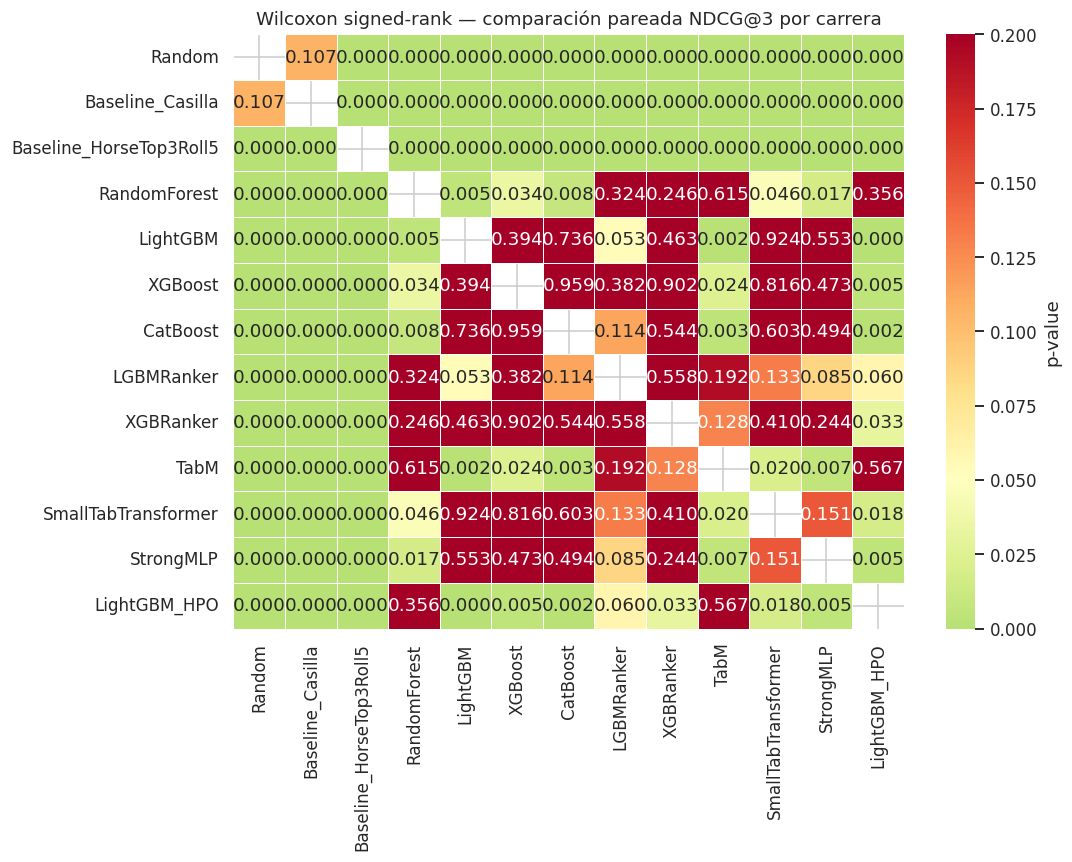

,model_a,model_b,n_races,mean_a,mean_b,mean_diff_a_minus_b,wilcoxon_stat,p_value
8,Random,TabM,1133,0.4429,0.6042,-0.1613,93294.5000,0.0000
108,TabM,Random,1133,0.6042,0.4429,0.1613,93294.5000,0.0000
11,Random,LightGBM_HPO,1133,0.4429,0.6055,-0.1626,102103.0000,0.0000
144,LightGBM_HPO,Random,1133,0.6055,0.4429,0.1626,102103.0000,0.0000
36,RandomForest,Random,1133,0.6024,0.4429,0.1595,102742.0000,0.0000
2,Random,RandomForest,1133,0.4429,0.6024,-0.1595,102742.0000,0.0000
84,LGBMRanker,Random,1133,0.5991,0.4429,0.1563,98260.5000,0.0000
6,Random,LGBMRanker,1133,0.4429,0.5991,-0.1563,98260.5000,0.0000
60,XGBoost,Random,1133,0.5935,0.4429,0.1507,104497.0000,0.0000
4,Random,XGBoost,1133,0.4429,0.5935,-0.1507,104497.0000,0.0000


In [48]:
# ============================================================
# SECCIÓN 9.1 — WILCOXON PAREADO DESDE MÉTRICAS POR CARRERA
# ============================================================

from scipy.stats import wilcoxon
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

if per_race_all is None or len(per_race_all) == 0:
    print("⚠️ No hay per_race_all. No se puede calcular Wilcoxon.")
else:
    possible_gid_cols = ["gid", "carrera_id", "race_id"]
    gid_col = next((c for c in possible_gid_cols if c in per_race_all.columns), None)

    if gid_col is None:
        raise ValueError("No encuentro columna de carrera en per_race_all.")

    metric_col = "ndcg"

    if metric_col not in per_race_all.columns:
        raise ValueError(f"No existe {metric_col} en per_race_all.")

    ref_model = final_official.iloc[0]["model"]
    print(f"Modelo de referencia: {ref_model}")

    models_ndcg = {}

    for model_name in per_race_all["model"].unique():
        tmp = (
            per_race_all[per_race_all["model"] == model_name]
            .set_index(gid_col)[metric_col]
        )
        models_ndcg[model_name] = tmp

    names = list(models_ndcg.keys())
    M = np.full((len(names), len(names)), np.nan)

    rows = []

    for i, a in enumerate(names):
        for j, b in enumerate(names):
            if i == j:
                continue

            common = models_ndcg[a].index.intersection(models_ndcg[b].index)

            if len(common) < 30:
                continue

            x = models_ndcg[a].loc[common].values
            y = models_ndcg[b].loc[common].values

            try:
                stat, p = wilcoxon(x, y, zero_method="wilcox")
                M[i, j] = p
            except Exception:
                stat, p = np.nan, np.nan

            rows.append({
                "model_a": a,
                "model_b": b,
                "n_races": len(common),
                "mean_a": float(np.mean(x)),
                "mean_b": float(np.mean(y)),
                "mean_diff_a_minus_b": float(np.mean(x - y)),
                "wilcoxon_stat": stat,
                "p_value": p
            })

    wilc = pd.DataFrame(M, index=names, columns=names)

    fig, ax = plt.subplots(figsize=(10, 8))
    sns.heatmap(
        wilc,
        annot=True,
        fmt=".3f",
        cmap="RdYlGn_r",
        center=0.05,
        vmin=0,
        vmax=0.2,
        linewidths=0.4,
        ax=ax,
        cbar_kws={"label": "p-value"}
    )
    ax.set_title("Wilcoxon signed-rank — comparación pareada NDCG@3 por carrera")
    plt.tight_layout()
    fig.savefig(REPORTS / "wilcoxon_pvalues_heatmap.png", dpi=150, bbox_inches="tight")
    plt.show()

    wilc.to_csv(REPORTS / "wilcoxon_pvalues.csv")

    wilcoxon_long_df = pd.DataFrame(rows)
    wilcoxon_long_df.to_csv(REPORTS / "wilcoxon_pvalues_long.csv", index=False)
    display(wilcoxon_long_df.sort_values("p_value").head(30))

Matriz de p-values Wilcoxon (NDCG@3 por carrera) — bajo = diferencia significativa:


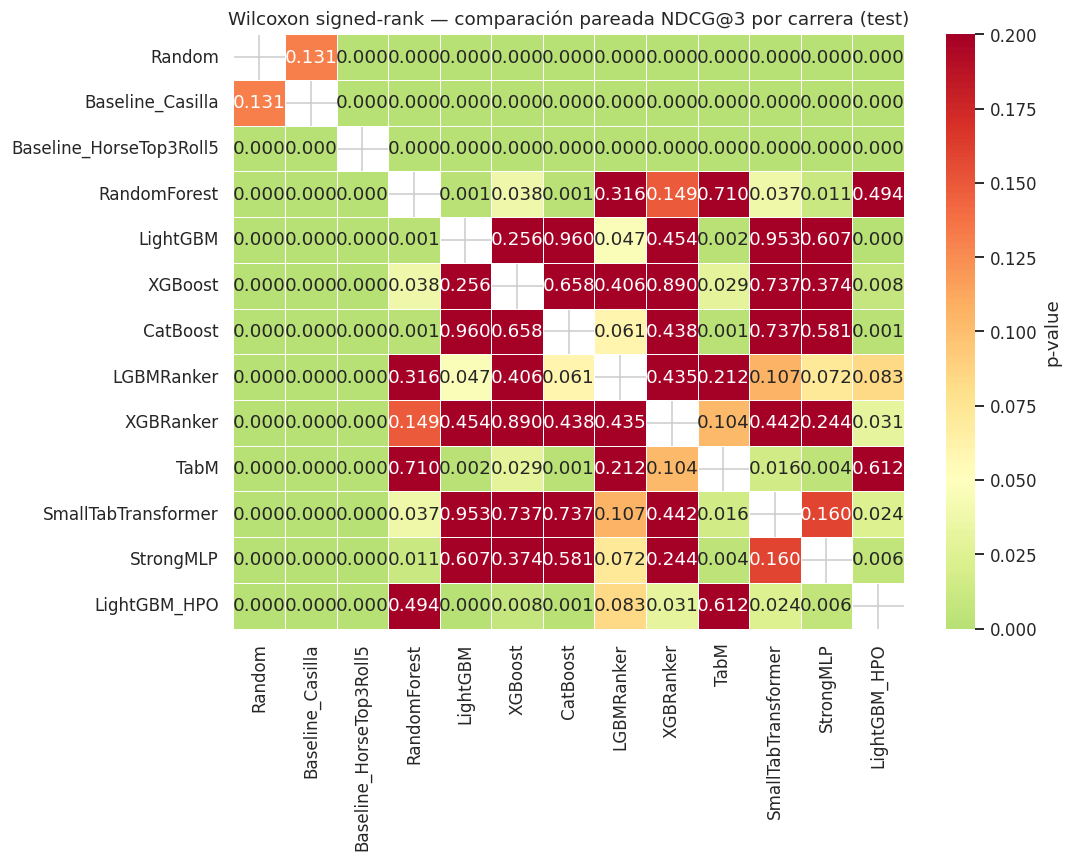

In [49]:
models_ndcg = {r['model']: r['_per_race'].set_index('gid')['ndcg'] for r in test_results if '_per_race' in r}
names = list(models_ndcg.keys())
M = np.full((len(names), len(names)), np.nan)
for i, a in enumerate(names):
    for j, b in enumerate(names):
        if i == j: continue
        common = models_ndcg[a].index.intersection(models_ndcg[b].index)
        if len(common) < 30: continue
        x = models_ndcg[a].loc[common].values
        y = models_ndcg[b].loc[common].values
        try:
            stat, p = wilcoxon(x, y, zero_method='wilcox')
            M[i, j] = p
        except: pass
wilc = pd.DataFrame(M, index=names, columns=names)
print('Matriz de p-values Wilcoxon (NDCG@3 por carrera) — bajo = diferencia significativa:')
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(wilc, annot=True, fmt='.3f', cmap='RdYlGn_r', center=0.05,
             vmin=0, vmax=0.2, linewidths=0.4, ax=ax,
             cbar_kws={'label':'p-value'})
ax.set_title('Wilcoxon signed-rank — comparación pareada NDCG@3 por carrera (test)')
plt.tight_layout()
wilc.to_csv(REPORTS / 'wilcoxon_pvalues.csv')

## 10. Calibración (Reliability Diagram + ECE)

Omitido en calibración por no estar en [0,1]: Baseline_Casilla


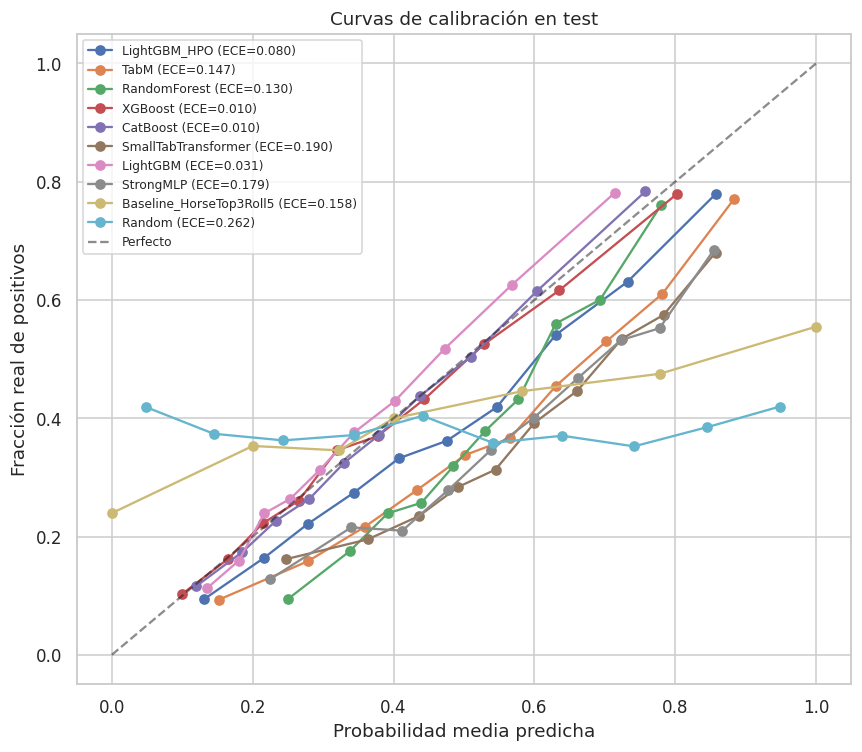

,model,ECE,mean_prediction,target_rate,min_prediction,max_prediction
0,CatBoost,0.0101,0.3836,0.3816,0.0355,0.9459
1,XGBoost,0.0105,0.3851,0.3816,0.0129,0.9786
2,LightGBM,0.0314,0.3581,0.3816,0.0658,0.8846
3,LightGBM_HPO,0.0801,0.4618,0.3816,0.0269,0.9701
4,RandomForest,0.1298,0.5115,0.3816,0.0602,0.8961
5,TabM,0.1471,0.5288,0.3816,0.0087,0.9758
6,Baseline_HorseTop3Roll5,0.1577,0.3958,0.3816,0.0000,1.0000
7,StrongMLP,0.1794,0.5610,0.3816,0.0185,0.9867
8,SmallTabTransformer,0.1899,0.5709,0.3816,0.0017,0.9883
9,Random,0.2622,0.4938,0.3816,0.0000,0.9997


In [50]:
# ============================================================
# SECCIÓN 10 — CALIBRACIÓN DESDE PREDICCIONES GUARDADAS
# ============================================================

from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

def ece(probs, y, n_bins=10):
    probs = np.asarray(probs, dtype=float)
    y = np.asarray(y, dtype=int)

    bins = np.linspace(0, 1, n_bins + 1)
    e = 0.0

    for i in range(n_bins):
        if i == n_bins - 1:
            mask = (probs >= bins[i]) & (probs <= bins[i + 1])
        else:
            mask = (probs >= bins[i]) & (probs < bins[i + 1])

        if mask.sum() == 0:
            continue

        e += mask.mean() * abs(y[mask].mean() - probs[mask].mean())

    return float(e)

def normalize_name(x):
    return str(x).lower().replace(" ", "").replace("-", "").replace("_", "")

def get_prediction_by_model_name(preds_npz, model_name):
    if preds_npz is None:
        return None

    if model_name in preds_npz.files:
        return preds_npz[model_name]

    target = normalize_name(model_name)

    aliases = {
        "lightgbmhpo": ["lightgbm_hpo", "pred_lgbm_hpo_test", "pred_best_test"],
        "randomforestsinwrdistancia": ["randomforest_sin_wr_distancia", "RandomForest_sin_wr_distancia"],
    }

    if target in aliases:
        for key in aliases[target]:
            if key in preds_npz.files:
                return preds_npz[key]

    for key in preds_npz.files:
        if normalize_name(key) == target:
            return preds_npz[key]

    return None

if preds_test_npz is None:
    print("⚠️ No hay predicciones guardadas. No se puede calcular calibración.")
else:
    if "y_test" in preds_test_npz.files:
        y_cal = preds_test_npz["y_test"]
    elif "y_test" in globals():
        y_cal = y_test
    else:
        raise ValueError("No encuentro y_test ni en NPZ ni en memoria.")

    probabilistic_models = [
        m for m in final_official["model"].tolist()
        if "Ranker" not in m
    ]

    fig, ax = plt.subplots(figsize=(8, 7))

    calibration_rows = []

    for name in probabilistic_models:
        pred = get_prediction_by_model_name(preds_test_npz, name)

        if pred is None:
            print(f"Omitido en calibración, no hay predicción guardada: {name}")
            continue

        scores = np.asarray(pred, dtype=float)

        if np.nanmin(scores) < -1e-6 or np.nanmax(scores) > 1 + 1e-6:
            print(f"Omitido en calibración por no estar en [0,1]: {name}")
            continue

        scores_clip = np.clip(scores, 0, 1)

        frac_pos, mean_pred = calibration_curve(
            y_cal,
            scores_clip,
            n_bins=10,
            strategy="quantile"
        )

        model_ece = ece(scores_clip, y_cal, n_bins=10)

        calibration_rows.append({
            "model": name,
            "ECE": model_ece,
            "mean_prediction": float(np.mean(scores_clip)),
            "target_rate": float(np.mean(y_cal)),
            "min_prediction": float(np.min(scores_clip)),
            "max_prediction": float(np.max(scores_clip))
        })

        ax.plot(
            mean_pred,
            frac_pos,
            marker="o",
            label=f"{name} (ECE={model_ece:.3f})"
        )

    ax.plot([0, 1], [0, 1], "k--", alpha=0.5, label="Perfecto")
    ax.set_title("Curvas de calibración en test")
    ax.set_xlabel("Probabilidad media predicha")
    ax.set_ylabel("Fracción real de positivos")
    ax.legend(loc="upper left", fontsize=8)
    plt.tight_layout()

    fig.savefig(
        REPORTS / "calibration_curves.png",
        dpi=130,
        bbox_inches="tight"
    )

    plt.show()

    calibration_df = (
        pd.DataFrame(calibration_rows)
        .sort_values("ECE")
        .reset_index(drop=True)
    )

    display(calibration_df)

    calibration_df.to_csv(
        REPORTS / "calibration_metrics.csv",
        index=False
    )

## 11. SHAP — Interpretabilidad del Mejor Modelo Tree

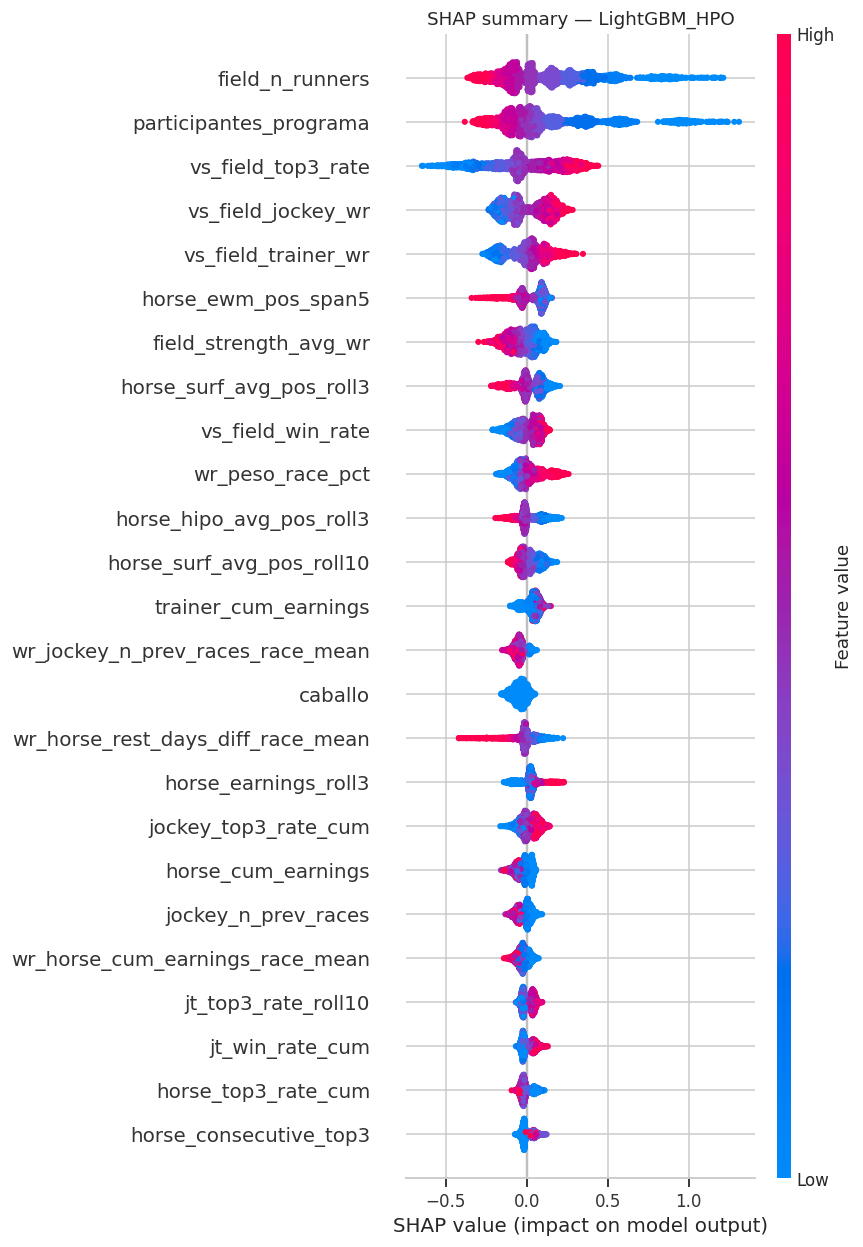

,feature,mean_abs_shap
0,field_n_runners,0.2309
1,participantes_programa,0.2055
2,vs_field_top3_rate,0.1807
3,vs_field_jockey_wr,0.1211
4,vs_field_trainer_wr,0.0958
5,horse_ewm_pos_span5,0.0753
6,field_strength_avg_wr,0.0718
7,horse_surf_avg_pos_roll3,0.0674
8,vs_field_win_rate,0.0624
9,wr_peso_race_pct,0.0622


In [51]:
# ============================================================
# SHAP — LightGBM_HPO / LightGBM
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import shap

    shap_model = None
    shap_model_name = None

    if "best_lgbm" in globals():
        shap_model = best_lgbm
        shap_model_name = "LightGBM_HPO"
    elif "lgbm" in globals():
        shap_model = lgbm
        shap_model_name = "LightGBM"

    if shap_model is None:
        print("⚠️ No hay LightGBM/LightGBM_HPO en memoria para SHAP.")
    else:
        sample_idx = np.random.RandomState(SEED).choice(
            len(X_test_imp),
            size=min(3000, len(X_test_imp)),
            replace=False
        )

        X_sample = X_test_imp[sample_idx]

        explainer = shap.TreeExplainer(shap_model)
        shap_values = explainer.shap_values(X_sample)

        if isinstance(shap_values, list):
            shap_values = shap_values[1]

        shap.summary_plot(
            shap_values,
            X_sample,
            feature_names=FEATURE_COLS,
            max_display=25,
            show=False
        )

        plt.title(f"SHAP summary — {shap_model_name}")
        plt.tight_layout()
        plt.savefig(
            REPORTS / f"shap_summary_{shap_model_name}.png",
            dpi=160,
            bbox_inches="tight"
        )
        plt.show()

        shap_importance = (
            pd.DataFrame({
                "feature": FEATURE_COLS,
                "mean_abs_shap": np.abs(shap_values).mean(axis=0)
            })
            .sort_values("mean_abs_shap", ascending=False)
            .reset_index(drop=True)
        )

        display(shap_importance.head(30))

        shap_importance.to_csv(
            REPORTS / f"shap_importance_{shap_model_name}.csv",
            index=False
        )

except Exception as e:
    print(f"⚠️ SHAP omitido por error: {e}")

Modelos incluidos:
['RandomForest', 'LightGBM', 'LightGBM_HPO', 'XGBoost', 'CatBoost', 'LGBMRanker', 'XGBRanker']
Nº variables candidatas: 26
['field_n_runners', 'participantes_programa', 'vs_field_top3_rate', 'vs_field_jockey_wr', 'vs_field_trainer_wr', 'horse_ewm_pos_span5', 'field_strength_avg_wr', 'horse_surf_avg_pos_roll3', 'vs_field_win_rate', 'wr_peso_race_pct', 'horse_hipo_avg_pos_roll3', 'horse_surf_avg_pos_roll10', 'trainer_cum_earnings', 'wr_jockey_n_prev_races_race_mean', 'caballo', 'wr_horse_rest_days_diff_race_mean', 'horse_earnings_roll3', 'jockey_top3_rate_cum', 'horse_cum_earnings', 'jockey_n_prev_races', 'wr_horse_cum_earnings_race_mean', 'jt_top3_rate_roll10', 'jt_win_rate_cum', 'horse_top3_rate_cum', 'horse_consecutive_top3', 'horse_top3_rate_roll5']

Calculando permutation importance para RandomForest...

Calculando permutation importance para LightGBM...

Calculando permutation importance para LightGBM_HPO...

Calculando permutation importance para XGBoost...

Cal

,model,feature,base_NDCG@3,drop_NDCG@3_mean,drop_NDCG@3_std,n_repeats,drop_NDCG@3_plot
0,CatBoost,participantes_programa,0.5911,0.0178,0.0017,5,0.0178
1,CatBoost,field_n_runners,0.5911,0.0145,0.0033,5,0.0145
2,CatBoost,vs_field_top3_rate,0.5911,0.0046,0.0041,5,0.0046
3,CatBoost,vs_field_jockey_wr,0.5911,0.0035,0.0024,5,0.0035
4,CatBoost,horse_cum_earnings,0.5911,0.0022,0.0010,5,0.0022
...,...,...,...,...,...,...,...
177,XGBoost,caballo,0.5935,0.0005,0.0004,5,0.0005
178,XGBoost,jockey_n_prev_races,0.5935,0.0003,0.0009,5,0.0003
179,XGBoost,wr_peso_race_pct,0.5935,0.0001,0.0014,5,0.0001
180,XGBoost,wr_horse_rest_days_diff_race_mean,0.5935,-0.0000,0.0015,5,0.0000


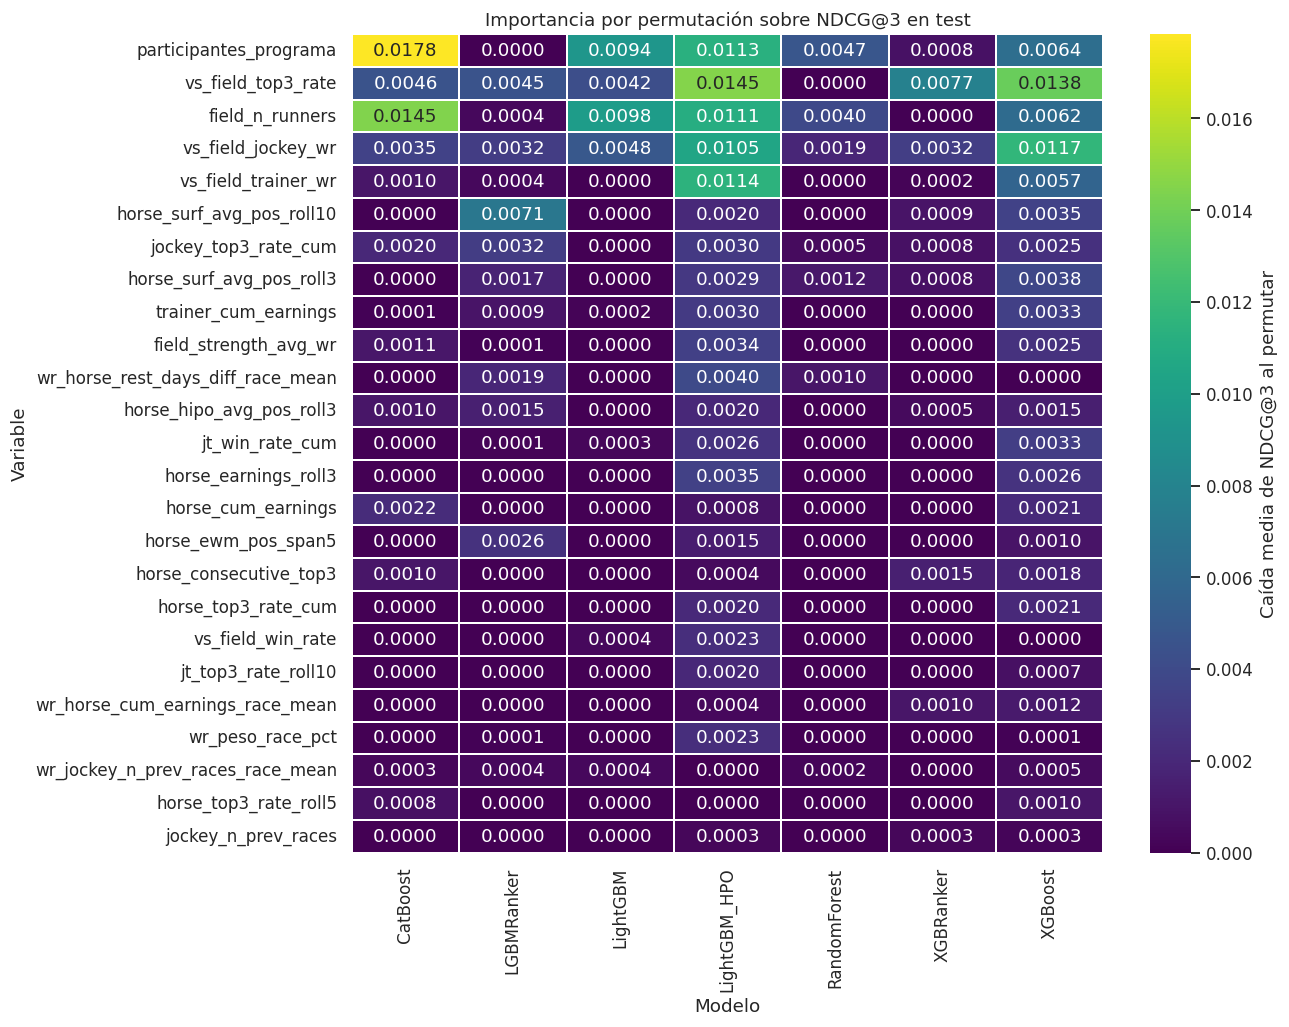

,feature,mean_drop_NDCG3,median_drop_NDCG3,max_drop_NDCG3,models_positive,n_models
0,participantes_programa,0.0072,0.0064,0.0178,6,7
1,vs_field_top3_rate,0.0070,0.0046,0.0145,6,7
2,field_n_runners,0.0065,0.0062,0.0145,6,7
3,vs_field_jockey_wr,0.0055,0.0035,0.0117,7,7
4,vs_field_trainer_wr,0.0025,0.0004,0.0114,5,7
5,jockey_top3_rate_cum,0.0015,0.0020,0.0032,6,7
6,horse_surf_avg_pos_roll10,0.0015,0.0009,0.0071,4,7
7,horse_surf_avg_pos_roll3,0.0012,0.0012,0.0038,5,7
8,trainer_cum_earnings,0.0006,0.0002,0.0033,5,7
9,jt_win_rate_cum,0.0006,0.0001,0.0033,4,7


In [52]:
# ============================================================
# Permutation importance comparativa sobre NDCG@3
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import seaborn as sns
    HAS_SEABORN = True
except Exception:
    HAS_SEABORN = False

try:
    import xgboost as xgb
except Exception:
    xgb = None

def mean_ndcg3(df_part, scores):
    return race_metrics(df_part, scores, k=3)["ndcg"].mean()

def as_catboost_frame(X):
    X_df = pd.DataFrame(X, columns=FEATURE_COLS)

    if "ENC_COLS" in globals():
        for col in ENC_COLS:
            if col in X_df.columns:
                X_df[col] = X_df[col].astype(int)

    return X_df

def permute_one_feature(X, j, rng):
    Xp = X.copy()
    Xp[:, j] = rng.permutation(Xp[:, j])
    return Xp

PERM_MODELS = {}

if "rf_hpo" in globals():
    PERM_MODELS["RandomForest_HPO"] = lambda X: rf_hpo.predict_proba(X)[:, 1]
elif "rf" in globals():
    PERM_MODELS["RandomForest"] = lambda X: rf.predict_proba(X)[:, 1]

if "lgbm" in globals():
    PERM_MODELS["LightGBM"] = lambda X: lgbm.predict(X)

if "best_lgbm" in globals():
    PERM_MODELS["LightGBM_HPO"] = lambda X: best_lgbm.predict(
        X,
        num_iteration=best_lgbm.best_iteration
    )

if "bst" in globals() and xgb is not None:
    PERM_MODELS["XGBoost"] = lambda X: bst.predict(xgb.DMatrix(X))

if "cb" in globals():
    PERM_MODELS["CatBoost"] = lambda X: cb.predict_proba(as_catboost_frame(X))[:, 1]

if "ranker_lgb" in globals():
    PERM_MODELS["LGBMRanker"] = lambda X: ranker_lgb.predict(X)

if "ranker_xgb" in globals():
    PERM_MODELS["XGBRanker"] = lambda X: ranker_xgb.predict(X)

print("Modelos incluidos:")
print(list(PERM_MODELS.keys()))

if len(PERM_MODELS) == 0:
    raise ValueError("No hay modelos en memoria para permutation importance.")

candidate_features = []

if "shap_importance" in globals():
    candidate_features += shap_importance.head(25)["feature"].tolist()

if "rf_imp" in globals():
    candidate_features += rf_imp.head(25)["feature"].tolist()

forced_features = [
    "wr_distancia_m_race_pct",
    "odds_win",
    "horse_top3_rate_roll5",
    "horse_hipo_avg_pos_roll3",
    "horse_surf_avg_pos_roll3",
    "field_n_runners"
]

for f in forced_features:
    if f in FEATURE_COLS:
        candidate_features.append(f)

if len(candidate_features) == 0:
    candidate_features = FEATURE_COLS[:30]

candidate_features = [f for f in dict.fromkeys(candidate_features) if f in FEATURE_COLS]
candidate_features = candidate_features[:35]

print(f"Nº variables candidatas: {len(candidate_features)}")
print(candidate_features)

N_REPEATS = 5
rng_master = np.random.default_rng(SEED)

perm_rows = []

for model_name, predict_fn in PERM_MODELS.items():
    print(f"\nCalculando permutation importance para {model_name}...")

    base_scores = predict_fn(X_test_imp)
    base_ndcg = mean_ndcg3(df_test, base_scores)

    for feature in candidate_features:
        j = FEATURE_COLS.index(feature)
        drops = []

        for rep in range(N_REPEATS):
            rng = np.random.default_rng(rng_master.integers(0, 1_000_000_000))
            Xp = permute_one_feature(X_test_imp, j, rng)
            perm_scores = predict_fn(Xp)
            perm_ndcg = mean_ndcg3(df_test, perm_scores)
            drops.append(base_ndcg - perm_ndcg)

        perm_rows.append({
            "model": model_name,
            "feature": feature,
            "base_NDCG@3": base_ndcg,
            "drop_NDCG@3_mean": float(np.mean(drops)),
            "drop_NDCG@3_std": float(np.std(drops)),
            "n_repeats": N_REPEATS
        })

perm_importance_df = pd.DataFrame(perm_rows)

perm_importance_df["drop_NDCG@3_plot"] = perm_importance_df["drop_NDCG@3_mean"].clip(lower=0)

perm_importance_df = (
    perm_importance_df
    .sort_values(["model", "drop_NDCG@3_mean"], ascending=[True, False])
    .reset_index(drop=True)
)

display(perm_importance_df)

perm_importance_df.to_csv(
    REPORTS / "permutation_importance_ndcg3_by_model.csv",
    index=False
)

feature_order = (
    perm_importance_df
    .groupby("feature")["drop_NDCG@3_plot"]
    .mean()
    .sort_values(ascending=False)
    .head(25)
    .index
    .tolist()
)

heat = (
    perm_importance_df
    .pivot_table(
        index="feature",
        columns="model",
        values="drop_NDCG@3_plot",
        aggfunc="mean"
    )
    .reindex(feature_order)
)

fig, ax = plt.subplots(figsize=(12, max(7, 0.38 * len(feature_order))))

if HAS_SEABORN:
    sns.heatmap(
        heat,
        cmap="viridis",
        linewidths=0.3,
        linecolor="white",
        annot=True,
        fmt=".4f",
        cbar_kws={"label": "Caída media de NDCG@3 al permutar"}
    )
else:
    im = ax.imshow(heat.values, aspect="auto")
    ax.set_xticks(np.arange(len(heat.columns)))
    ax.set_xticklabels(heat.columns, rotation=45, ha="right")
    ax.set_yticks(np.arange(len(heat.index)))
    ax.set_yticklabels(heat.index)
    fig.colorbar(im, ax=ax, label="Caída media de NDCG@3 al permutar")

ax.set_title("Importancia por permutación sobre NDCG@3 en test")
ax.set_xlabel("Modelo")
ax.set_ylabel("Variable")
plt.tight_layout()

fig.savefig(
    REPORTS / "permutation_importance_ndcg3_heatmap.png",
    dpi=180,
    bbox_inches="tight"
)

plt.show()

consensus_importance = (
    perm_importance_df
    .groupby("feature")
    .agg(
        mean_drop_NDCG3=("drop_NDCG@3_mean", "mean"),
        median_drop_NDCG3=("drop_NDCG@3_mean", "median"),
        max_drop_NDCG3=("drop_NDCG@3_mean", "max"),
        models_positive=("drop_NDCG@3_mean", lambda s: int((s > 0).sum())),
        n_models=("model", "nunique")
    )
    .sort_values("mean_drop_NDCG3", ascending=False)
    .reset_index()
)

display(consensus_importance.head(30))

consensus_importance.to_csv(
    REPORTS / "permutation_importance_ndcg3_consensus.csv",
    index=False
)

## 12. Resumen Final y Persistencia

In [53]:
# ============================================================
# SECCIÓN 12 — RESUMEN FINAL Y PERSISTENCIA OFICIAL
# ============================================================

import json
from datetime import datetime

final_official = (
    final_official
    .drop_duplicates(subset=["model"], keep="last")
    .sort_values("NDCG@3", ascending=False)
    .reset_index(drop=True)
)

print("\n=== RESULTADOS FINALES OFICIALES — TEST SET ===")

display(
    final_official.style.format({
        c: "{:.4f}"
        for c in ["AUC", "F1", "Brier", "NDCG@3", "MAP@3", "P@3", "HR@1", "HR@3", "Spearman"]
        if c in final_official.columns
    }).background_gradient(
        subset=[c for c in ["NDCG@3", "AUC", "MAP@3", "P@3"] if c in final_official.columns],
        cmap="Greens"
    )
)

final_official.to_csv(REPORTS / "model_results_test_official.csv", index=False)

best_name = final_official.iloc[0]["model"]
best_ndcg = float(final_official.iloc[0]["NDCG@3"])
best_auc = float(final_official.iloc[0]["AUC"]) if "AUC" in final_official.columns else None

print(f"\n🏆 MEJOR MODELO POR NDCG@3: {best_name} | NDCG@3={best_ndcg:.4f}")

predictions_to_save = {}

if preds_test_npz is not None:
    for key in preds_test_npz.files:
        predictions_to_save[key] = preds_test_npz[key]

if "pred_lgbm_hpo_test" in globals():
    predictions_to_save["lightgbm_hpo"] = pred_lgbm_hpo_test
elif "pred_best_test" in globals():
    predictions_to_save["lightgbm_hpo"] = pred_best_test

if "pred_rf_no_wr_dist_test" in globals():
    predictions_to_save["randomforest_sin_wr_distancia"] = pred_rf_no_wr_dist_test

if len(predictions_to_save) > 0:
    np.savez_compressed(
        MODELS_DIR / "test_predictions_official.npz",
        **predictions_to_save
    )

manifest_final = {
    "run_finalized_at": datetime.now().isoformat(timespec="seconds"),
    "best_model_by_ndcg3": best_name,
    "best_ndcg3": best_ndcg,
    "best_auc_of_best_model": best_auc,
    "n_models": int(len(final_official)),
    "models": list(final_official["model"]),
    "has_predictions_checkpoint": bool(PREDICTIONS_CHECKPOINT.exists()),
    "has_per_race_checkpoint": bool(PER_RACE_CHECKPOINT.exists()),
    "source": "checkpoint_based_finalization"
}

if "train" in globals() and "val" in globals() and "test" in globals():
    group_col = "race_id" if "race_id" in train.columns else "carrera_id"
    manifest_final.update({
        "n_train_rows": int(len(train)),
        "n_val_rows": int(len(val)),
        "n_test_rows": int(len(test)),
        "n_train_races": int(train[group_col].nunique()) if group_col in train.columns else None,
        "n_val_races": int(val[group_col].nunique()) if group_col in val.columns else None,
        "n_test_races": int(test[group_col].nunique()) if group_col in test.columns else None,
        "train_date_min": str(train["fecha"].min()) if "fecha" in train.columns else None,
        "train_date_max": str(train["fecha"].max()) if "fecha" in train.columns else None,
        "val_date_min": str(val["fecha"].min()) if "fecha" in val.columns else None,
        "val_date_max": str(val["fecha"].max()) if "fecha" in val.columns else None,
        "test_date_min": str(test["fecha"].min()) if "fecha" in test.columns else None,
        "test_date_max": str(test["fecha"].max()) if "fecha" in test.columns else None,
    })

with open(REPORTS / "modeling_manifest_final.json", "w", encoding="utf-8") as f:
    json.dump(manifest_final, f, indent=2)

summary_lines = [
    "# Resumen final de modelado",
    "",
    f"- Mejor modelo por NDCG@3: **{best_name}**",
    f"- NDCG@3: **{best_ndcg:.4f}**",
]

if best_auc is not None:
    summary_lines.append(f"- AUC del mejor modelo por NDCG@3: **{best_auc:.4f}**")

summary_lines += [
    "",
    "## Tabla final de resultados",
    "",
    final_official.to_markdown(index=False)
]

with open(REPORTS / "modeling_summary.md", "w", encoding="utf-8") as f:
    f.write("\n".join(summary_lines))

print("\n✅ Artefactos oficiales guardados:")
print("-", REPORTS / "model_results_test_official.csv")
print("-", REPORTS / "modeling_manifest_final.json")
print("-", REPORTS / "modeling_summary.md")
print("-", MODELS_DIR / "test_predictions_official.npz")


=== RESULTADOS FINALES OFICIALES — TEST SET ===


,model,AUC,F1,Brier,NDCG@3,NDCG@3_CI,MAP@3,MAP@3_CI,P@3,HR@1,HR@3,Spearman
0,LightGBM_HPO,0.7476,0.6087,0.2001,0.6055,"[0.589, 0.621]",0.5064,"[0.489, 0.524]",0.5834,0.6761,0.9462,0.3581
1,TabM,0.7454,0.6276,0.2176,0.6042,"[0.588, 0.619]",0.5019,"[0.485, 0.518]",0.5837,0.6726,0.9523,0.3658
2,RandomForest,0.7398,0.6189,0.2155,0.6024,"[0.586, 0.618]",0.5015,"[0.484, 0.518]",0.5822,0.6655,0.9523,0.3558
3,LGBMRanker,0.6911,0.1552,0.3032,0.5991,"[0.582, 0.615]",0.5010,"[0.484, 0.519]",0.5775,0.6681,0.9391,0.3535
4,XGBRanker,0.6868,0.0023,0.3335,0.5939,"[0.578, 0.609]",0.4937,"[0.476, 0.510]",0.5743,0.6549,0.9391,0.3427
5,XGBoost,0.7437,0.5510,0.1944,0.5935,"[0.578, 0.608]",0.4926,"[0.476, 0.510]",0.5725,0.6584,0.9444,0.3388
6,CatBoost,0.7387,0.5341,0.1956,0.5911,"[0.575, 0.607]",0.4912,"[0.473, 0.508]",0.5728,0.6496,0.9338,0.3395
7,SmallTabTransformer,0.7012,0.6004,0.2458,0.5904,"[0.574, 0.606]",0.4888,"[0.472, 0.505]",0.5755,0.6355,0.9444,0.3202
8,LightGBM,0.7409,0.4977,0.1963,0.5902,"[0.574, 0.607]",0.4906,"[0.473, 0.508]",0.5699,0.6523,0.9365,0.3412
9,StrongMLP,0.7066,0.6096,0.2404,0.5863,"[0.570, 0.602]",0.4853,"[0.468, 0.501]",0.5731,0.6258,0.9426,0.3203



🏆 MEJOR MODELO POR NDCG@3: LightGBM_HPO | NDCG@3=0.6055

✅ Artefactos oficiales guardados:
- /content/data/reports/model_results_test_official.csv
- /content/data/reports/modeling_manifest_final.json
- /content/data/reports/modeling_summary.md
- /content/data/models/test_predictions_official.npz
